In [1]:
# 1)  라이브러리 임포트 및 장치 설정
#  시스템 및 시간 관련 표준 라이브러리
import os
import datetime

#  PyTorch 관련 라이브러리
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms

#  시각화 및 데이터 전처리 도구
import numpy as np
import matplotlib.pylab as plt

#  연산 장치(Device) 설정
# GPU(CUDA) 사용 가능 여부를 확인하여 연산 장치를 할당
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"현재 사용 중인 장치: {device}")


현재 사용 중인 장치: cuda


In [2]:
# 2) 데이터 전처리 및 로더 설정]
# 이미지 전처리
#  ToTensor(): 이미지를 PyTorch 텐서 형식으로 바꾸며, 픽셀 값을 [0, 1] 범위로 자동 스케일링
transform = transforms.Compose([transforms.ToTensor()])

# MNIST 데이터셋 로드:
train_dataset = datasets.MNIST(root="./data_gen", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data_gen", train=False, transform=transform, download=True)

# 학습 데이터 로더: 배치 100, 매 epoch마다 섞음(shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=0, pin_memory=False)
# 테스트 데이터 로더: 배치 100, 순서 고정(shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=0)

In [3]:
# 3) VAE 인코더 클래스 정의
class Encoder(nn.Module):
   #자식 클래스의 초기화
    def __init__(self, input_dim, hidden_dim, latent_dim):
       # 부모 클래스 생성자 호출
        super(Encoder, self).__init__()
        
        # 입력층에서 제1 은닉층으로의 선형 변환 (특징 추출 시작)
        self.input1 = nn.Linear(input_dim, hidden_dim)
        
        # 제1 은닉층에서 제2 은닉층으로의 선형 변환 (특징 학습 심화)
        self.input2 = nn.Linear(hidden_dim, hidden_dim)
        
        # 잠재 변수의 평균(mean, μ)을 계산하는 출력층
        self.mean = nn.Linear(hidden_dim, latent_dim)
        
        # 잠재 변수의 로그 분산(log_var, log σ^2)을 계산하는 출력층
        self.var = nn.Linear(hidden_dim, latent_dim)

        # 활성화 함수: 생성 모델의 기울기 소실 방지에 효과적인 LeakyReLU 사용
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        # 첫 번째 은닉층 통과 및 비선형성 추가
        h_ = self.LeakyReLU(self.input1(x))        
        # 두 번째 은닉층 통과
        h_ = self.LeakyReLU(self.input2(h_))
        
        # 잠재 공간의 평균 벡터 계산
        mean = self.mean(h_)        
        # 잠재 공간의 로그 분산 벡터 계산
        log_var = self.var(h_)
        
        return mean, log_var

In [4]:
# 4) VAE 디코더 클래스 정의
class Decoder(nn.Module):
    #자식 클래스의 초기화
    def __init__(self, latent_dim, hidden_dim, output_dim):
        # 부모 클래스 생성자 호출
        super(Decoder, self).__init__()
        
        # 잠재 벡터 z를 다시 은닉층 차원으로 확장
        self.hidden1 = nn.Linear(latent_dim, hidden_dim)
        
        # 은닉층 간의 차원 유지 및 특징 복원
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
        
        # 최종적으로 원래 이미지 크기(예: 784)로 데이터 복원
        self.output = nn.Linear(hidden_dim, output_dim)

        # 음수 기울기를 허용하는 LeakyReLU 활성화 함수
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        # 1번째 은닉층 통과 (입력 x는 샘플링된 잠재 벡터 z)
        h = self.LeakyReLU(self.hidden1(x))
        
        # 2번째 은닉층 통과
        h = self.LeakyReLU(self.hidden2(h))
        
        # Sigmoid 함수를 적용하여 픽셀 값을 0~1 범위로 생성 (MNIST 재구축에 최적)
        x_hat = torch.sigmoid(self.output(h))
        
        return x_hat


In [5]:
# 5) VAE 전체 구조를 관리하는 통합 모델 클래스 (Wrapper 클래스)
class Model(nn.Module):
    # 생성자: 외부에서 정의한 인코더와 디코더 객체를 받아 초기화
    def __init__(self, Encoder, Decoder):
        # 부모 클래스 생성자 호출
        super(Model, self).__init__()
        
        # 미리 생성된 인코더와 디코더 모듈을 멤버 변수로 등록하여 통합
        self.Encoder = Encoder
        self.Decoder = Decoder

    # 재매개변수화 트릭: 확률적인 샘플링을 결정론적인 수식으로 변환하여 역전파를 가능하게 함
    def reparameterization(self, mean, std):
        # 표준정규분포 N(0, I)로부터 무작위 잡음 epsilon을 생성
        # .to(device)를 통해 연산 장치(GPU/CPU) 위치를 일치
        epsilon = torch.randn_like(std).to(device)
        
        # z = μ + σ * ε 연산을 수행 (여기서 *는 아다마르 곱)        
        z = mean + std * epsilon
        return z

    # 순전파(Forward Pass): 데이터의 입력부터 복원 이미지 생성까지의 전체 흐름 정의
    def forward(self, x):
        # 1. 인코딩 단계: 입력 이미지를 전달하여 잠재 분포의 파라미터(μ, log_var)를 추출
        mean, log_var = self.Encoder(x)
        
        # 2. 로그 분산을 표준편차로 변환: σ = exp(0.5 * log_var)
        # 수학적 안정성을 위해 log (variance) 형태로 학습 후 표준편차로 변환
        std = torch.exp(0.5 * log_var)
        
        # 3. 샘플링 단계: 추출된 μ와 σ를 사용하여 잠재 변수 z를 샘플링
        z = self.reparameterization(mean, std)
        
        # 4. 디코딩 단계: 잠재 변수 z로부터 원래의 이미지를 복원(x_hat)
        x_hat = self.Decoder(z)
        
        # 생성된 이미지와 함께 손실 함수 계산에 필요한 평균과 로그 분산을 반환
        return x_hat, mean, log_var

In [6]:
# 6) 모델 생성 및 환경 설정
# 차원 및 학습 관련 하이퍼파라미터 설정
x_dim = 784          # 입력 데이터 차원 (28 x 28 = 784)
hidden_dim = 400     # 은닉층 노드 수
latent_dim = 2     # 잠재 공간 차원
epochs = 30          # 전체 데이터셋 반복 횟수
batch_size = 100     # 한 번에 학습할 데이터 묶음 크기

# 인코더 및 디코더 객체 생성 (각각의 생성자 호출 및 초기화)
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

# 전체 VAE 모델 조립 후 지정된 장치(GPU/CPU)로 이동
# (참고: Model 클래스는 Encoder와 Decoder를 통합 관리하는 Wrapper 클래스임)
model = Model(Encoder=encoder, Decoder=decoder).to(device)

# 모델을 학습 모드로 설정 (드롭아웃, 배치 정규화 등이 활성화됨)
model.train()


Model(
  (Encoder): Encoder(
    (input1): Linear(in_features=784, out_features=400, bias=True)
    (input2): Linear(in_features=400, out_features=400, bias=True)
    (mean): Linear(in_features=400, out_features=2, bias=True)
    (var): Linear(in_features=400, out_features=2, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
  (Decoder): Decoder(
    (hidden1): Linear(in_features=2, out_features=400, bias=True)
    (hidden2): Linear(in_features=400, out_features=400, bias=True)
    (output): Linear(in_features=400, out_features=784, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
)

In [7]:
#7) VAE의 손실 함수: 복원 손실(Binary Cross Entropy)과 KL 발산의 합
def loss_function(x, x_hat, mean, log_var):
    # 복원 손실 (Reconstruction Loss): 원본과 복원 이미지 사이의 이진 교차 엔트로피 계산
    # MNIST 화소범위가 0~1이지만 숫자/배경에 따라 1 또는 0에 가까운 값이므로 베르누이 분포로 가정  BCE를 손실함수로 사용
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    
    # KL 손실 (KLD): 잠재 공간의 분포가 표준정규분포와 얼마나 유사한지 측정
    # 수식: -0.5 * sum(1 + log(σ^2) - μ^2 - σ^2)
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    
    return reproduction_loss, KLD

# 최적화 알고리즘: Adam Optimizer 사용, 학습률(Learning Rate)은 0.001로 설정
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
#8) 모델 학습
def train(epoch, model, train_loader, optimizer):
    # 에폭별 총 손실을 누적할 변수 초기화 (나중에 전체 평균을 구하기 위함)
    train_loss = 0

    # 모델을 학습 모드로 설정 (Dropout이나 Batch Normalization 등이 있을 경우 필수)
    model.train()

    # 데이터 로더를 통해 배치 단위로 데이터를 가져옴 (x: 이미지, _: 라벨은 사용 안 함)
    for batch_idx, (x, _) in enumerate(train_loader):
        # 1. 입력 데이터 크기 및 장치 설정
        # 마지막 배치는 설정한 배치 크기보다 작을 수 있으므로 현재 텐서의 크기(N)를 직접 가져옴
        cur_bs = x.size(0)

        # 4차원 이미지 (N, 1, 28, 28)를 2차원 벡터 (N, 784)로 평탄화(Flatten)
        # .to(device)를 통해 데이터를 GPU 혹은 CPU 메모리로 이동
        x = x.view(cur_bs, x_dim).to(device)

        # 2. 최적화 도구의 그래디언트 초기화
        # 이전 배치 계산에서 남은 기울기(Gradient) 값을 0으로 비움
        optimizer.zero_grad()

        # 3. 순전파(Forward Pass) 실행
        # 입력 데이터를 넣어 복원 이미지(x_hat), 잠재 공간의 평균(mean)과 로그 분산(log_var) 획득
        x_hat, mean, log_var = model(x)

        # 4. 손실 함수(Loss Function) 계산
        # 이전에 정의한 loss_function을 호출하여 복원 손실(BCE)과 정규화 손실(KLD)의 합을 구함
        BCE, KLD = loss_function(x, x_hat, mean, log_var)
        loss = BCE + KLD

        # 5. 역전파(Backpropagation) 및 가중치 업데이트
        # 전체 손실(Total Loss)을 합산한 뒤, 에폭 전체 손실 변수에 누적 (Python 숫자로 변환)
        train_loss += loss.item()
        
        # 오차 역전파를 통해 각 파라미터별 기울기 계산
        loss.backward()
        
        # 계산된 기울기를 바탕으로 모델의 파라미터(Weight)를 한 단계 업데이트
        optimizer.step()

        # 6. 학습 진행 상황 출력 (100개 배치마다 한 번씩)
        if batch_idx % 100 == 0:
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * cur_bs,
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item() / cur_bs  # 현재 배치의 샘플당 평균 손실
                )
            )

    # 에폭 종료 후 전체 데이터셋에 대한 샘플당 평균 손실 출력
    # Loss 총합 / 전체 데이터 개수
    avg_epoch_loss = train_loss / len(train_loader.dataset)
    print("======> Epoch: {} Average loss: {:.4f}".format(epoch, avg_epoch_loss))
    
    return avg_epoch_loss

In [9]:
#9) 복원이미지 시각화
def show_reconstruction(comparison_tensor, n):
    """
    원본 이미지와 VAE 복원 이미지를 나란히 시각화하는 함수
    :param comparison_tensor: (2*n, 1, 28, 28) 형태의 텐서 [원본 n개, 복원 n개]
    :param n: 한 줄에 표시할 이미지 개수
    """
    # 1. 텐서를 numpy 배열로 변환 및 차원 조정 (C, H, W) -> (H, W)
    # comparison_tensor는 (2n, 1, 28, 28)이므로 하나씩 꺼내어 시각화
    images = comparison_tensor.squeeze().numpy()

    # 2. 시각화 영역 설정
    # 위 줄은 원본(Real), 아래 줄은 복원(Reconstruction)
    plt.figure(figsize=(n * 1.5, 3))
    
    for i in range(n):
        # --- 위 줄: 원본 이미지 ---
        ax1 = plt.subplot(2, n, i + 1)
        plt.imshow(images[i], cmap='gray')
        if i == 0:
            ax1.set_ylabel("Original", rotation=0, labelpad=40, verticalalignment='center')
        plt.axis('off')

        # --- 아래 줄: 복원 이미지 ---
        ax2 = plt.subplot(2, n, i + 1 + n)
        plt.imshow(images[i + n], cmap='gray')
        if i == 0:
            ax2.set_ylabel("Reconstructed", rotation=0, labelpad=40, verticalalignment='center')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
#10) 
def test(epoch, model, test_loader):
    # 1. 평가 모드 설정
    # 학습 시에만 필요한 Dropout이나 Batch Normalization 기능을 비활성화하여 동작을 고정
    model.eval()
    test_loss = 0    
    # 기울기(Gradient) 계산 비활성화: 
    # 테스트 단계에서는 가중치를 업데이트하지 않으므로 메모리 절약과 연산 속도 향상을 위해 필수적
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(test_loader):
            # 2. 데이터 전처리 및 장치 할당
            cur_bs = x.size(0) # 마지막 배치의 크기 변동에 대응
            
            # (N, 1, 28, 28) 형태의 이미지를 (N, 784) 벡터로 평탄화하여 장치(GPU/CPU)로 전송
            x = x.view(cur_bs, x_dim).to(device)

            # 3. 순전파(Forward Pass)
            # 학습된 인코더와 디코더를 통해 복원 이미지(x_hat)와 분포 파라미터를 얻음
            x_hat, mean, log_var = model(x)

            # 4. 손실(Loss) 계산
            # 원본과 복원본 사이의 오차(BCE)와 잠재 공간의 정규화 정도(KLD)를 합산
            BCE, KLD = loss_function(x, x_hat, mean, log_var)
            loss = BCE + KLD

            # 5. 테스트 손실 누적
            # 전체 테스트 셋에 대한 평균 오차를 구하기 위해 배치별 손실을 합산
            test_loss += loss.item()

            # 6. 결과 시각화 준비 (첫 번째 배치의 이미지만 수행)
            if batch_idx == 0: 
                # 시각화할 이미지 개수 설정 (최대 8개)
                n = min(cur_bs, 8)

                # 원본 이미지(x)와 복원 이미지(x_hat)를 나란히 비교하기 위해 결합
                # 결과물: [원본1, ..., 원본n, 복원1, ..., 복원n] 형태의 텐서
                comparison = torch.cat([x[:n], x_hat[:n]], dim=0)

                # 그리드 생성을 위해 다시 4차원 이미지 형태 (2n, 1, 28, 28)로 변환
                comparison = comparison.view(2 * n, 1, 28, 28)
                          
                # plt를 활용해 시가가화
                show_reconstruction(comparison.cpu(), n)

    # 에폭 종료 후 테스트 데이터셋 전체에 대한 샘플당 평균 손실 출력
    avg_test_loss = test_loss / len(test_loader.dataset)
    print("======> Test set loss: {:.4f}".format(avg_test_loss))
    
    return avg_test_loss

In [11]:
#11) 표준정규분포에서 무작위로 샘플링하여 새로운 이미지를 생성하는 함수
def generate_images(epoch, model, n=16):
    # 평가 모드로 생성(드롭아웃/BN 있으면 고정)
    model.eval()
    with torch.no_grad():
        # prior p(z)=N(0,I)에서 z 샘플링
        z = torch.randn(n, latent_dim).to(device)

        # 디코더로 이미지 생성
        x_gen = model.Decoder(z)  # (n, 784)

        # (n, 784) -> (n, 1, 28, 28)로 reshape
        x_gen = x_gen.view(n, 1, 28, 28)

        # GPU 텐서를 CPU로 복사(.cpu()) 후 Numpy 변환(.numpy())
        # permute(1, 2, 0)은 (C, H, W)를 Matplotlib 형식인 (H, W, C)로 변경
        plt.figure(figsize=(8, 8))
        grid = torchvision.utils.make_grid(x_gen, nrow=int(np.sqrt(n)), normalize=True)
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        plt.title(f"Generated Images at Epoch {epoch}")
        plt.axis('off')
        plt.show()

    # 다시 학습 모드로 복귀
    model.train()

In [12]:
#12) 손실 곡선 시각화 함수

def plot_loss_curve(history):
    """
    학습 및 테스트 손실 변화를 시각화하는 함수
    """
    plt.figure(figsize=(12, 6))
    
    # 1. 학습 손실 (Train Loss) 그래프
    plt.plot(history['train_loss'], label='Train Total Loss', color='blue', linestyle='-')
    
    # 2. 테스트 손실 (Test Loss) 그래프
    plt.plot(history['test_loss'], label='Test Total Loss', color='red', linestyle='--')

    plt.title('VAE Training & Test Loss Curve', fontsize=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # y축이 너무 클 경우를 대비해 로그 스케일을 고려할 수도 있습니다.
    # plt.yscale('log') 

    plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

Train Epoch: 1 [0/60000 (0%)]	Loss: 544.644102
Train Epoch: 1 [10000/60000 (17%)]	Loss: 181.396094
Train Epoch: 1 [20000/60000 (33%)]	Loss: 173.794902
Train Epoch: 1 [30000/60000 (50%)]	Loss: 170.946680
Train Epoch: 1 [40000/60000 (67%)]	Loss: 161.369629
Train Epoch: 1 [50000/60000 (83%)]	Loss: 166.885449
======> Epoch: 1 Average loss: 178.2884


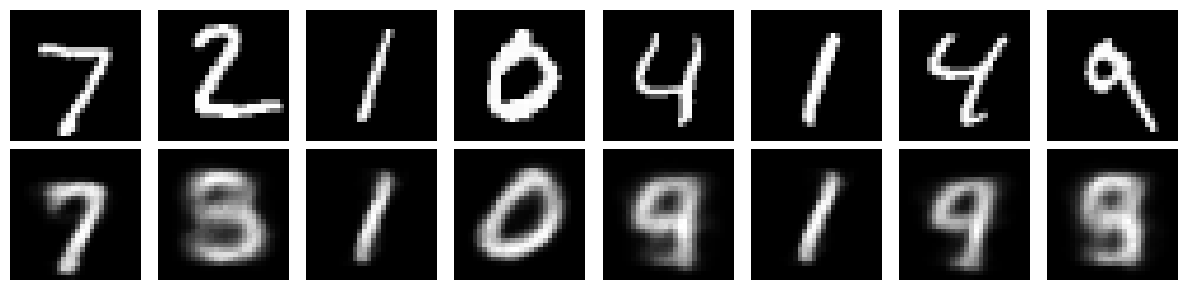

======> Test set loss: 164.0472


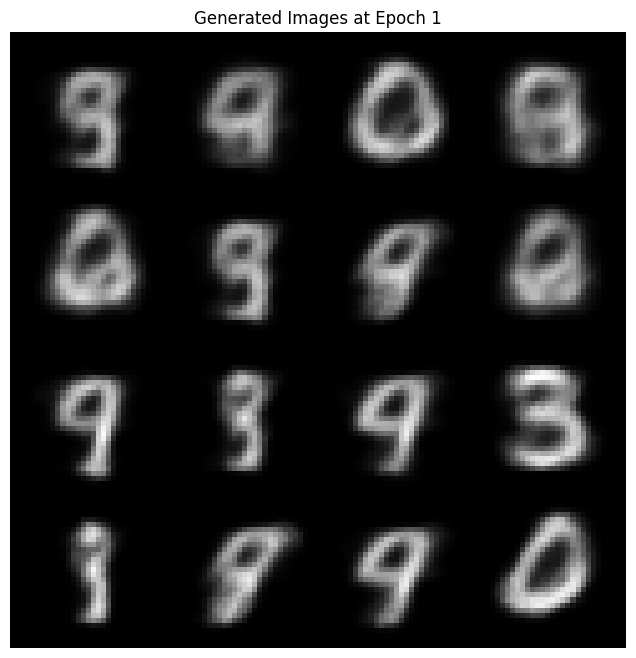

Train Epoch: 2 [0/60000 (0%)]	Loss: 168.110703
Train Epoch: 2 [10000/60000 (17%)]	Loss: 161.856729
Train Epoch: 2 [20000/60000 (33%)]	Loss: 158.438643
Train Epoch: 2 [30000/60000 (50%)]	Loss: 159.478779
Train Epoch: 2 [40000/60000 (67%)]	Loss: 162.337598
Train Epoch: 2 [50000/60000 (83%)]	Loss: 159.574072
======> Epoch: 2 Average loss: 161.1994


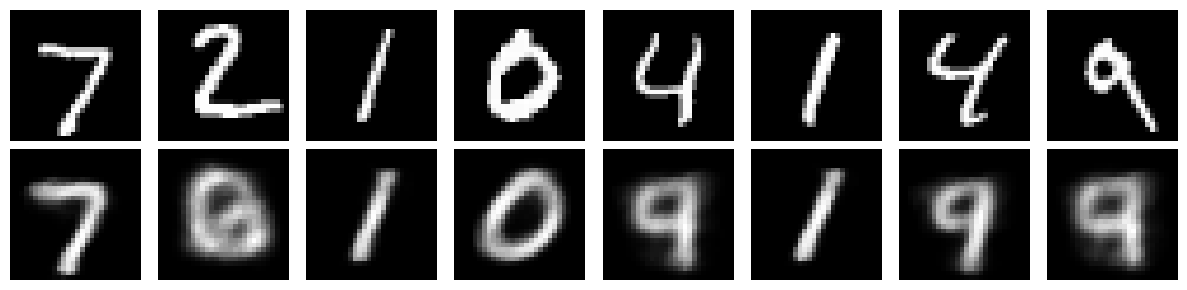

======> Test set loss: 161.3734


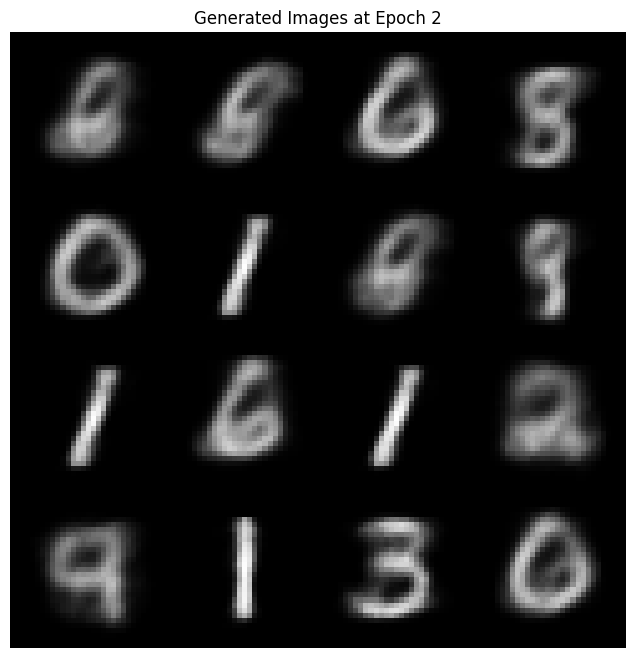

Train Epoch: 3 [0/60000 (0%)]	Loss: 167.525254
Train Epoch: 3 [10000/60000 (17%)]	Loss: 160.704980
Train Epoch: 3 [20000/60000 (33%)]	Loss: 157.718164
Train Epoch: 3 [30000/60000 (50%)]	Loss: 155.910645
Train Epoch: 3 [40000/60000 (67%)]	Loss: 152.783730
Train Epoch: 3 [50000/60000 (83%)]	Loss: 152.385596
======> Epoch: 3 Average loss: 156.9761


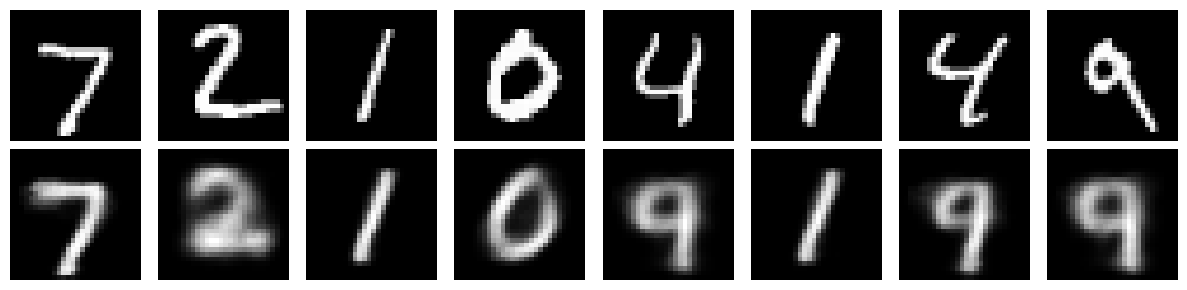

======> Test set loss: 155.7611


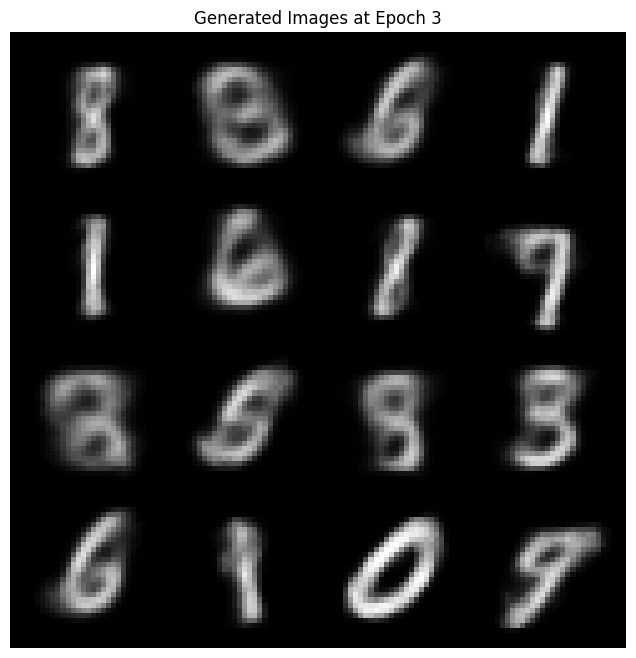

Train Epoch: 4 [0/60000 (0%)]	Loss: 152.791729
Train Epoch: 4 [10000/60000 (17%)]	Loss: 156.806494
Train Epoch: 4 [20000/60000 (33%)]	Loss: 158.912627
Train Epoch: 4 [30000/60000 (50%)]	Loss: 160.054004
Train Epoch: 4 [40000/60000 (67%)]	Loss: 153.045820
Train Epoch: 4 [50000/60000 (83%)]	Loss: 152.613506
======> Epoch: 4 Average loss: 154.3281


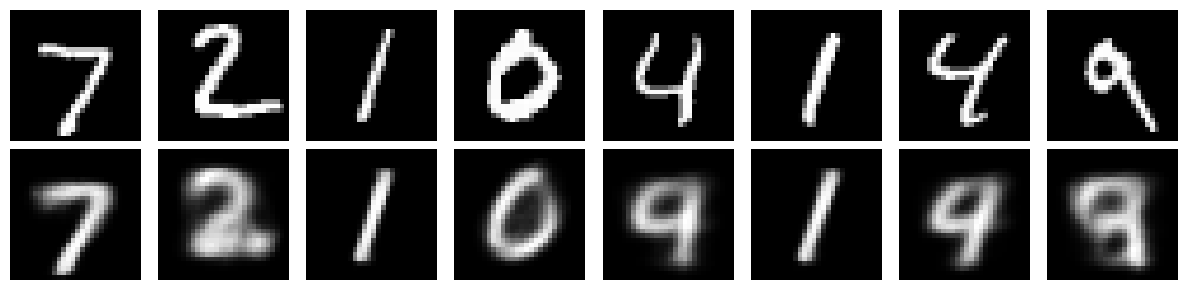

======> Test set loss: 153.7201


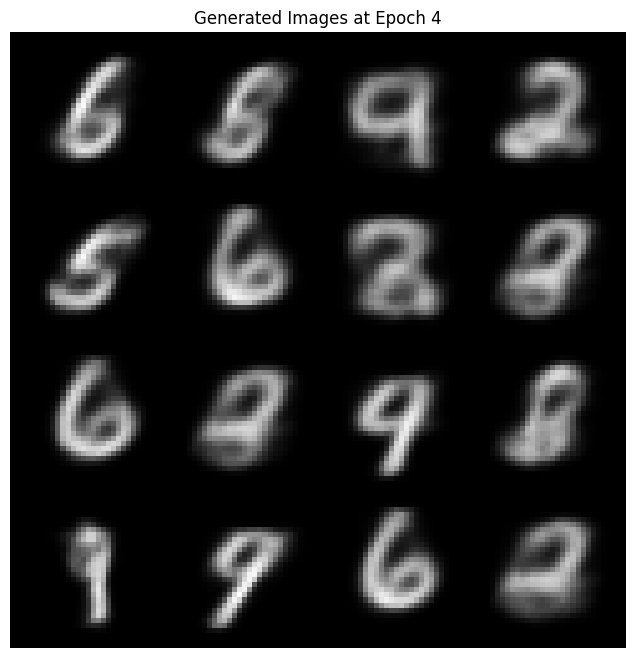

Train Epoch: 5 [0/60000 (0%)]	Loss: 155.522910
Train Epoch: 5 [10000/60000 (17%)]	Loss: 148.864111
Train Epoch: 5 [20000/60000 (33%)]	Loss: 148.892188
Train Epoch: 5 [30000/60000 (50%)]	Loss: 151.649609
Train Epoch: 5 [40000/60000 (67%)]	Loss: 151.556865
Train Epoch: 5 [50000/60000 (83%)]	Loss: 143.344639
======> Epoch: 5 Average loss: 152.4979


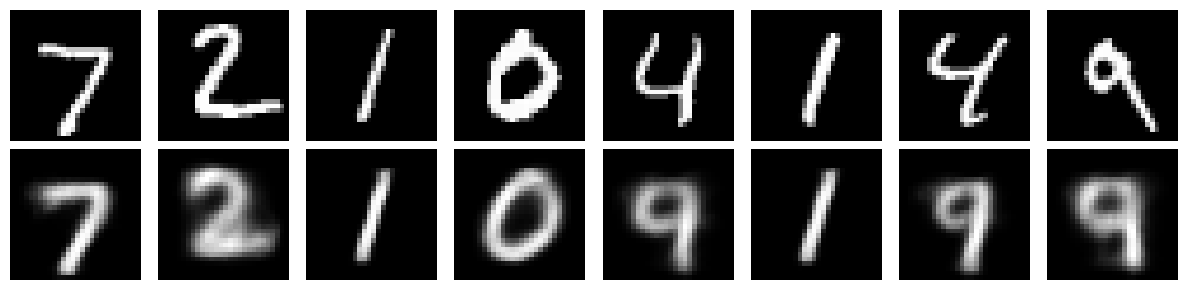

======> Test set loss: 151.5155


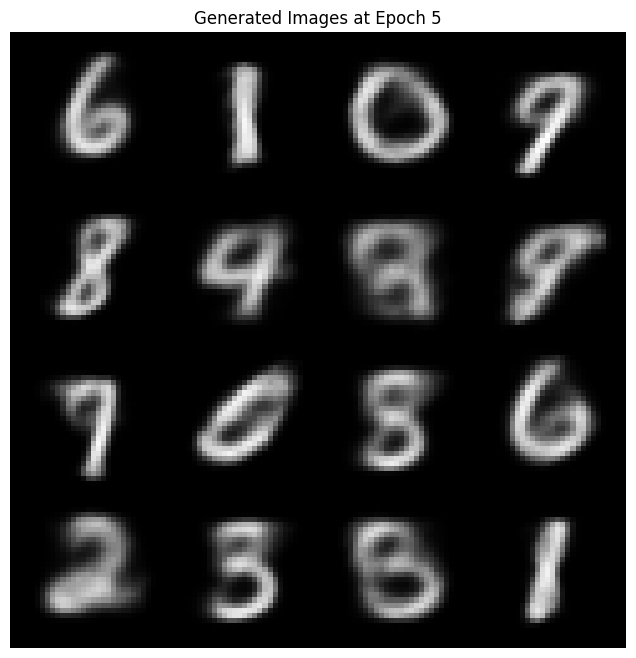

Train Epoch: 6 [0/60000 (0%)]	Loss: 149.206641
Train Epoch: 6 [10000/60000 (17%)]	Loss: 150.844883
Train Epoch: 6 [20000/60000 (33%)]	Loss: 149.916025
Train Epoch: 6 [30000/60000 (50%)]	Loss: 145.858867
Train Epoch: 6 [40000/60000 (67%)]	Loss: 145.251865
Train Epoch: 6 [50000/60000 (83%)]	Loss: 146.876123
======> Epoch: 6 Average loss: 151.1014


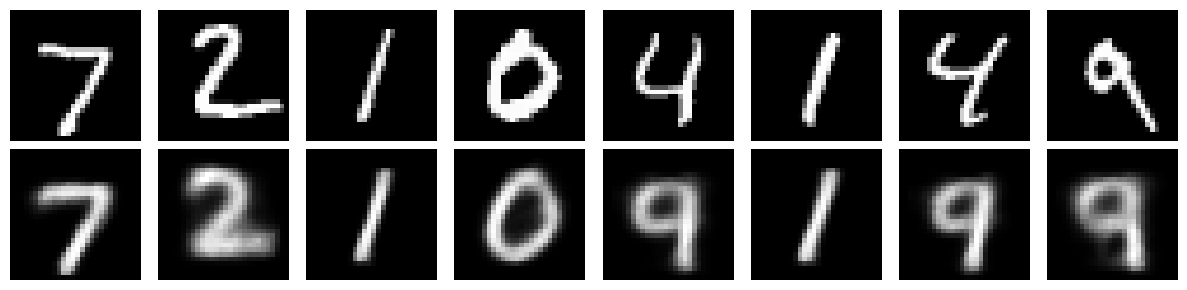

======> Test set loss: 150.4915


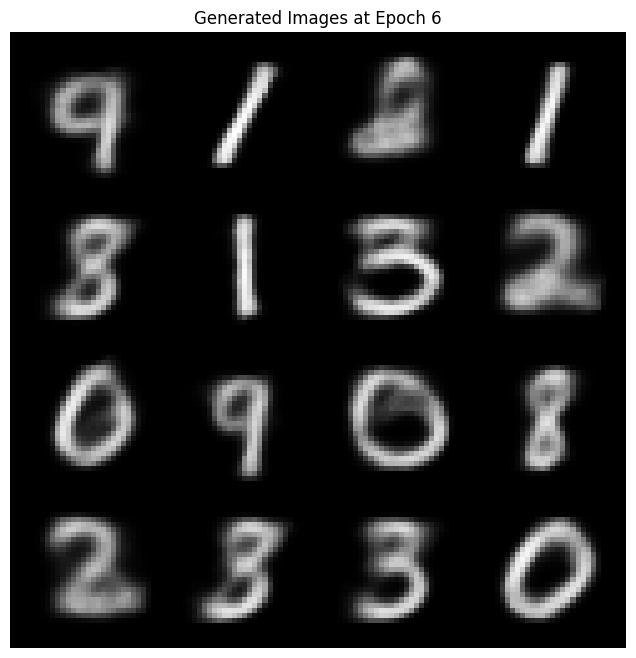

Train Epoch: 7 [0/60000 (0%)]	Loss: 143.085273
Train Epoch: 7 [10000/60000 (17%)]	Loss: 152.260430
Train Epoch: 7 [20000/60000 (33%)]	Loss: 144.296309
Train Epoch: 7 [30000/60000 (50%)]	Loss: 150.008945
Train Epoch: 7 [40000/60000 (67%)]	Loss: 153.533008
Train Epoch: 7 [50000/60000 (83%)]	Loss: 149.181338
======> Epoch: 7 Average loss: 150.1717


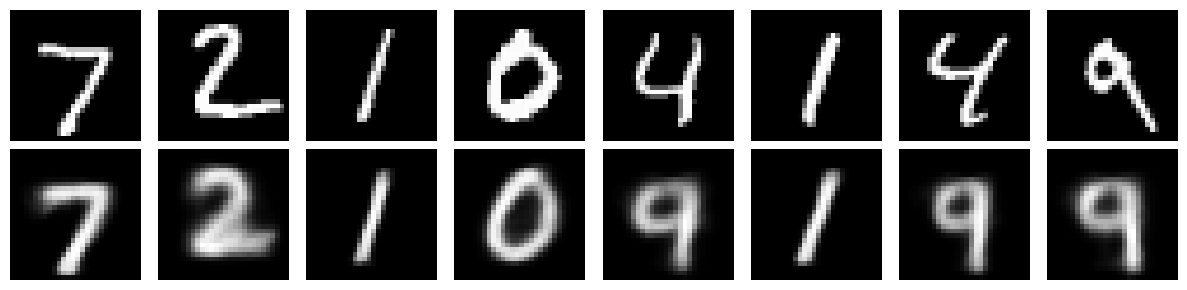

======> Test set loss: 149.5395


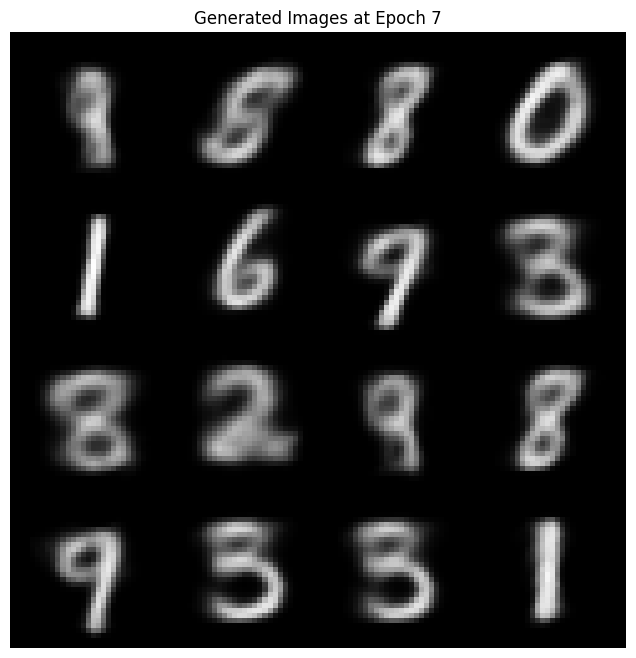

Train Epoch: 8 [0/60000 (0%)]	Loss: 149.399063
Train Epoch: 8 [10000/60000 (17%)]	Loss: 148.204863
Train Epoch: 8 [20000/60000 (33%)]	Loss: 153.841299
Train Epoch: 8 [30000/60000 (50%)]	Loss: 146.607266
Train Epoch: 8 [40000/60000 (67%)]	Loss: 149.780791
Train Epoch: 8 [50000/60000 (83%)]	Loss: 137.779902
======> Epoch: 8 Average loss: 149.1594


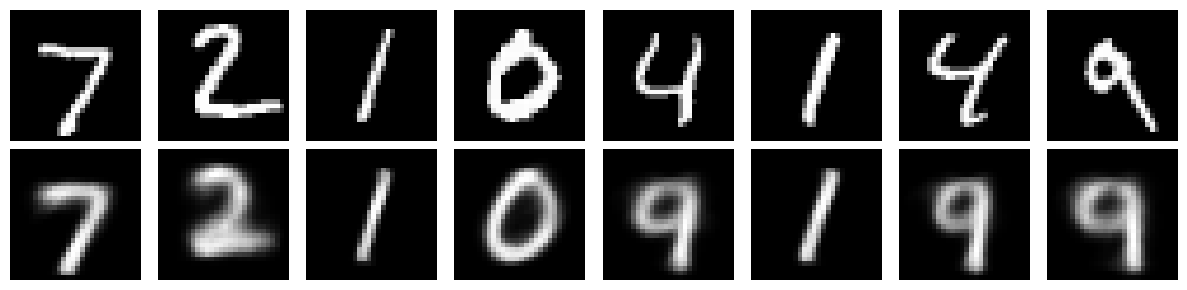

======> Test set loss: 148.9025


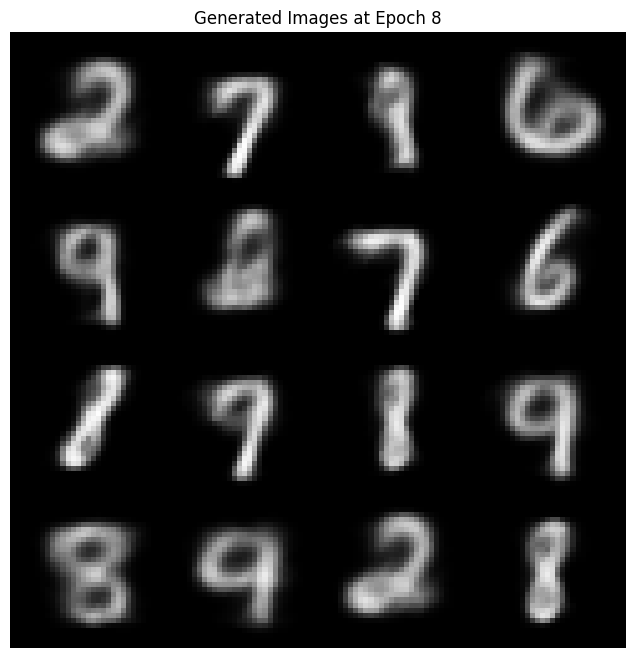

Train Epoch: 9 [0/60000 (0%)]	Loss: 146.736113
Train Epoch: 9 [10000/60000 (17%)]	Loss: 141.317314
Train Epoch: 9 [20000/60000 (33%)]	Loss: 142.640176
Train Epoch: 9 [30000/60000 (50%)]	Loss: 145.517979
Train Epoch: 9 [40000/60000 (67%)]	Loss: 150.356582
Train Epoch: 9 [50000/60000 (83%)]	Loss: 145.868145
======> Epoch: 9 Average loss: 148.4615


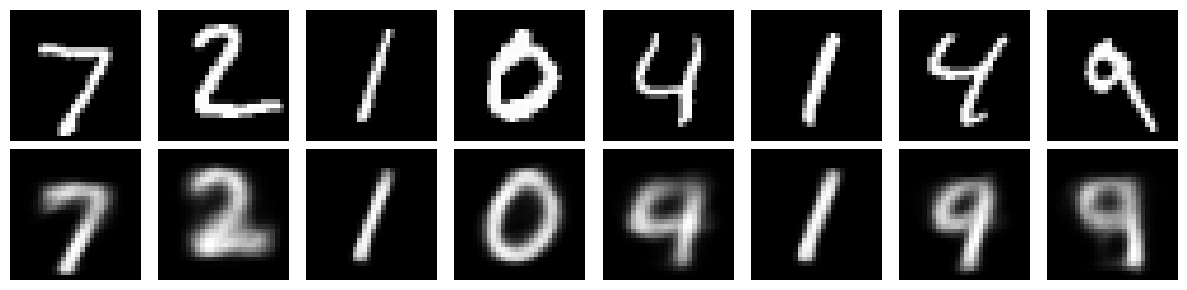

======> Test set loss: 150.4744


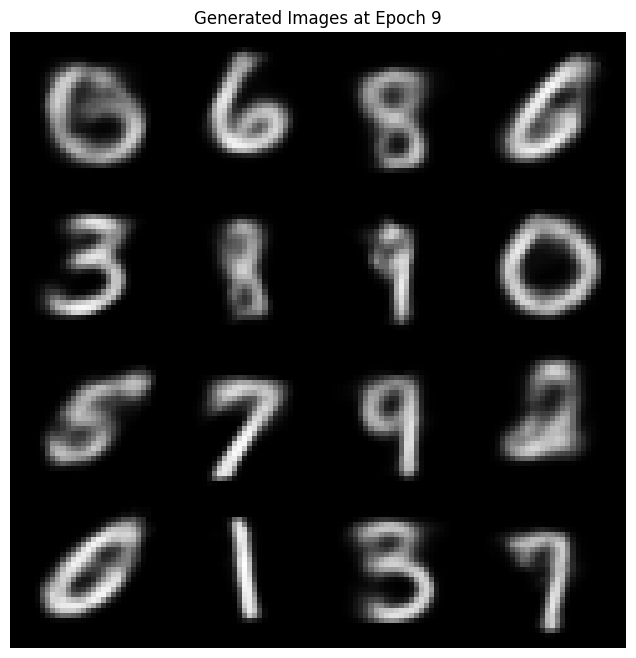

Train Epoch: 10 [0/60000 (0%)]	Loss: 148.145400
Train Epoch: 10 [10000/60000 (17%)]	Loss: 153.206729
Train Epoch: 10 [20000/60000 (33%)]	Loss: 156.401152
Train Epoch: 10 [30000/60000 (50%)]	Loss: 152.134893
Train Epoch: 10 [40000/60000 (67%)]	Loss: 146.960967
Train Epoch: 10 [50000/60000 (83%)]	Loss: 142.360518
======> Epoch: 10 Average loss: 147.8893


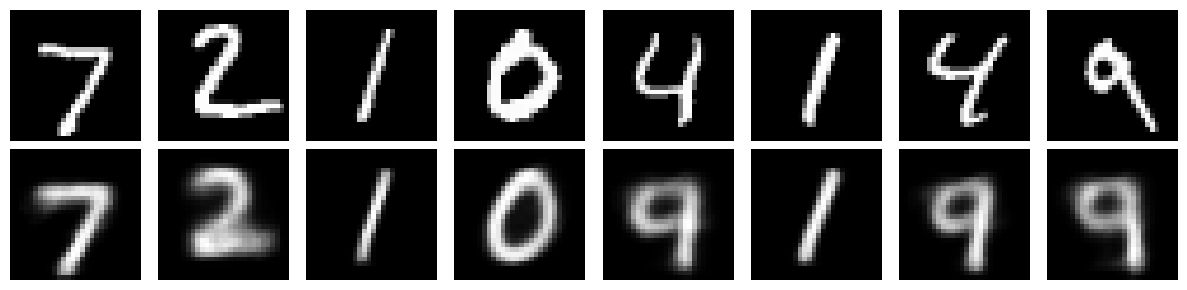

======> Test set loss: 148.0071


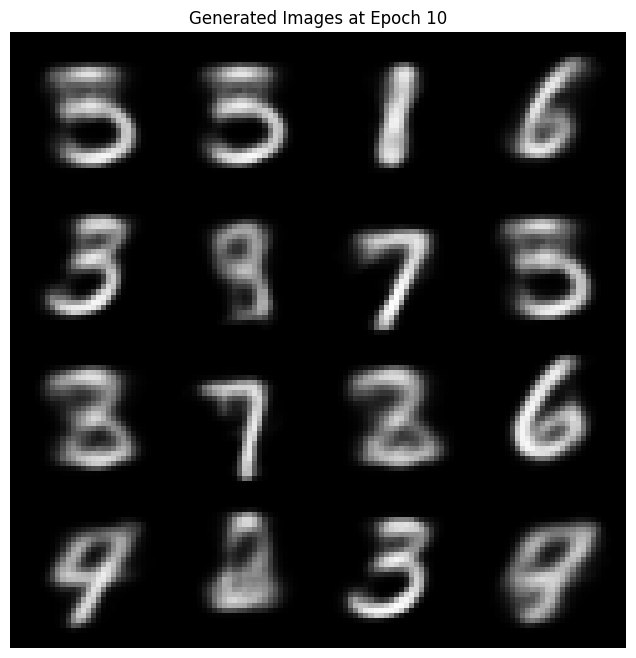

Train Epoch: 11 [0/60000 (0%)]	Loss: 138.548730
Train Epoch: 11 [10000/60000 (17%)]	Loss: 142.548926
Train Epoch: 11 [20000/60000 (33%)]	Loss: 145.708281
Train Epoch: 11 [30000/60000 (50%)]	Loss: 137.917227
Train Epoch: 11 [40000/60000 (67%)]	Loss: 139.483994
Train Epoch: 11 [50000/60000 (83%)]	Loss: 151.224297
======> Epoch: 11 Average loss: 147.4470


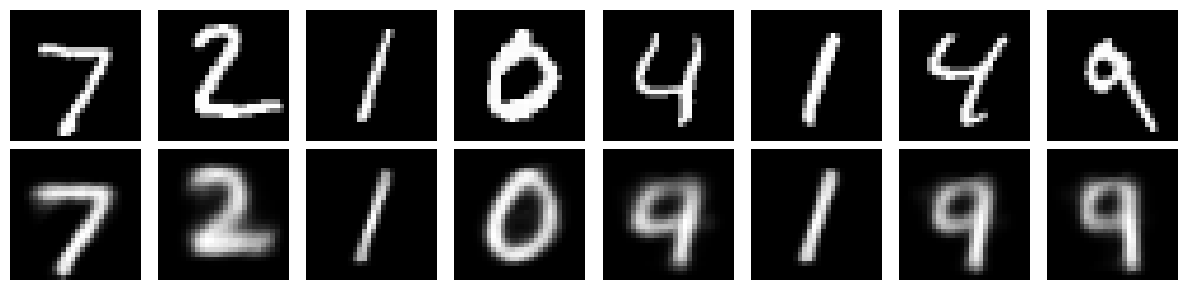

======> Test set loss: 148.3893


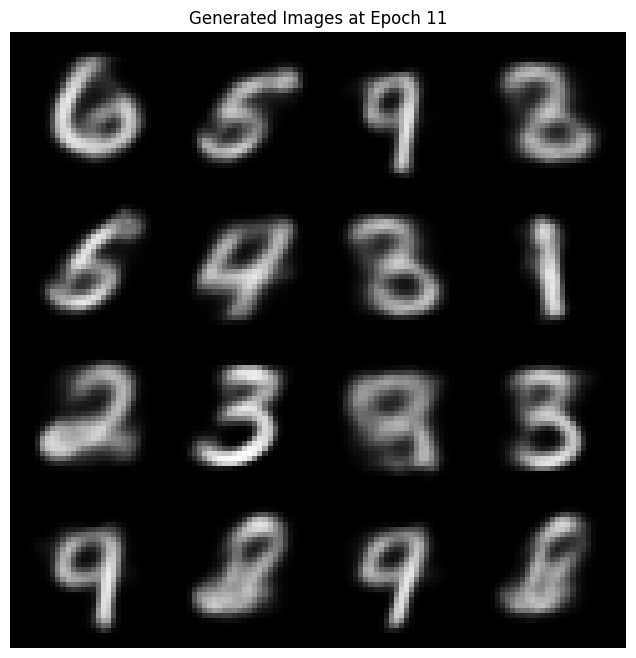

Train Epoch: 12 [0/60000 (0%)]	Loss: 145.329404
Train Epoch: 12 [10000/60000 (17%)]	Loss: 147.051055
Train Epoch: 12 [20000/60000 (33%)]	Loss: 144.560732
Train Epoch: 12 [30000/60000 (50%)]	Loss: 151.027510
Train Epoch: 12 [40000/60000 (67%)]	Loss: 143.131445
Train Epoch: 12 [50000/60000 (83%)]	Loss: 148.959053
======> Epoch: 12 Average loss: 147.1155


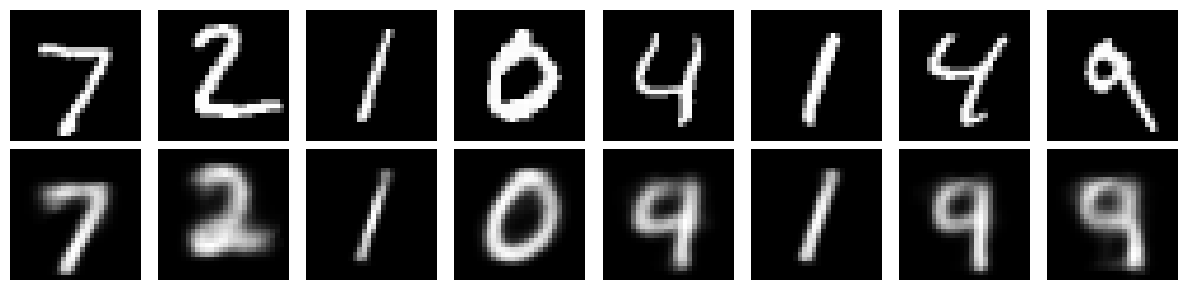

======> Test set loss: 148.5104


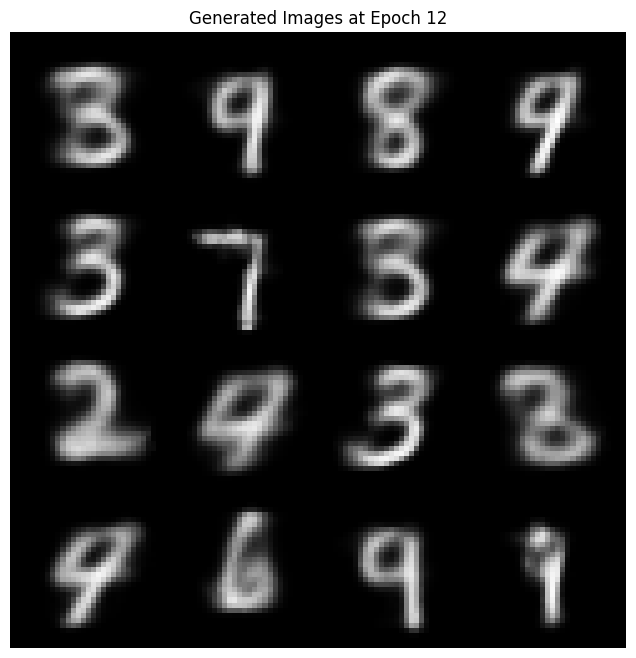

Train Epoch: 13 [0/60000 (0%)]	Loss: 148.991494
Train Epoch: 13 [10000/60000 (17%)]	Loss: 148.428848
Train Epoch: 13 [20000/60000 (33%)]	Loss: 153.243057
Train Epoch: 13 [30000/60000 (50%)]	Loss: 143.675537
Train Epoch: 13 [40000/60000 (67%)]	Loss: 153.291133
Train Epoch: 13 [50000/60000 (83%)]	Loss: 153.674570
======> Epoch: 13 Average loss: 146.6966


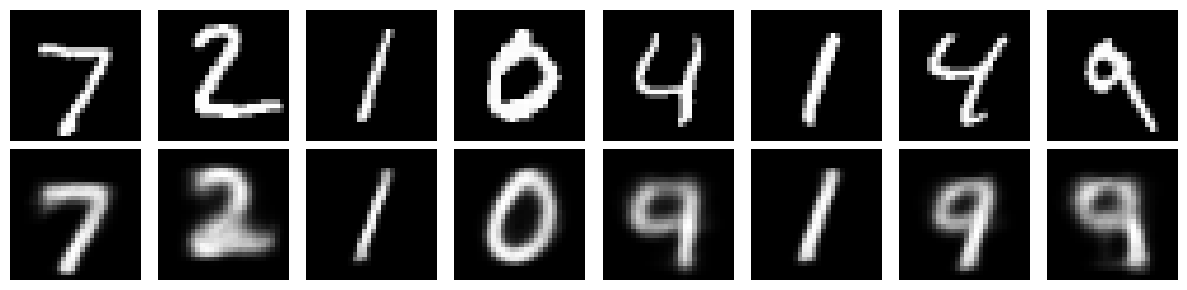

======> Test set loss: 147.7784


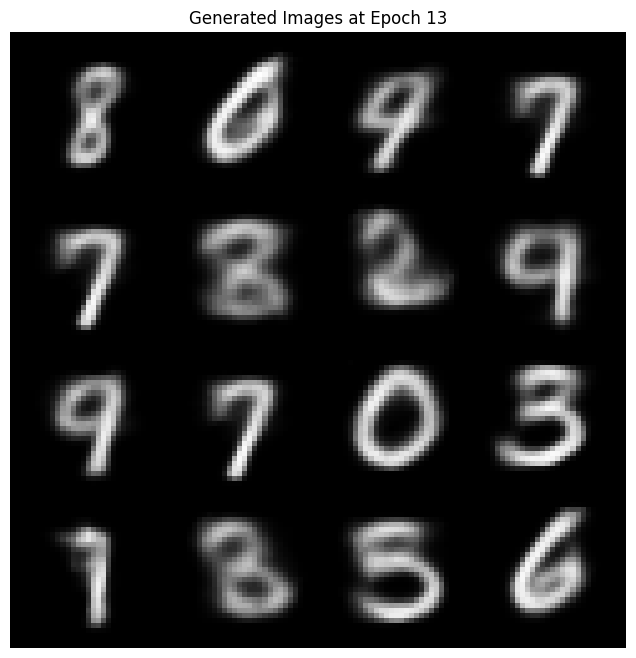

Train Epoch: 14 [0/60000 (0%)]	Loss: 141.610156
Train Epoch: 14 [10000/60000 (17%)]	Loss: 145.224922
Train Epoch: 14 [20000/60000 (33%)]	Loss: 146.590352
Train Epoch: 14 [30000/60000 (50%)]	Loss: 143.773184
Train Epoch: 14 [40000/60000 (67%)]	Loss: 151.058750
Train Epoch: 14 [50000/60000 (83%)]	Loss: 148.587402
======> Epoch: 14 Average loss: 146.1406


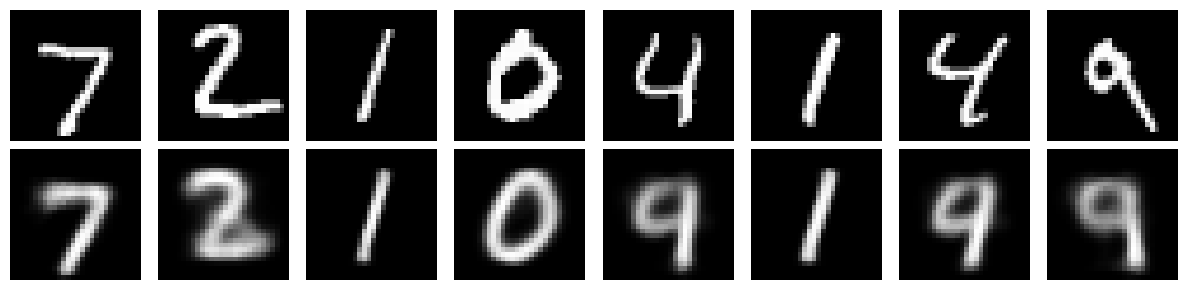

======> Test set loss: 147.5886


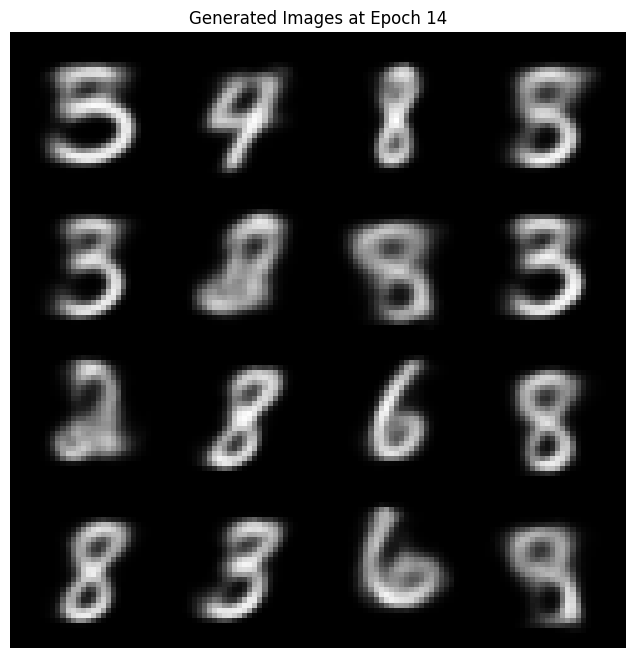

Train Epoch: 15 [0/60000 (0%)]	Loss: 151.464365
Train Epoch: 15 [10000/60000 (17%)]	Loss: 146.151553
Train Epoch: 15 [20000/60000 (33%)]	Loss: 154.870186
Train Epoch: 15 [30000/60000 (50%)]	Loss: 149.164541
Train Epoch: 15 [40000/60000 (67%)]	Loss: 139.057764
Train Epoch: 15 [50000/60000 (83%)]	Loss: 148.622549
======> Epoch: 15 Average loss: 145.9228


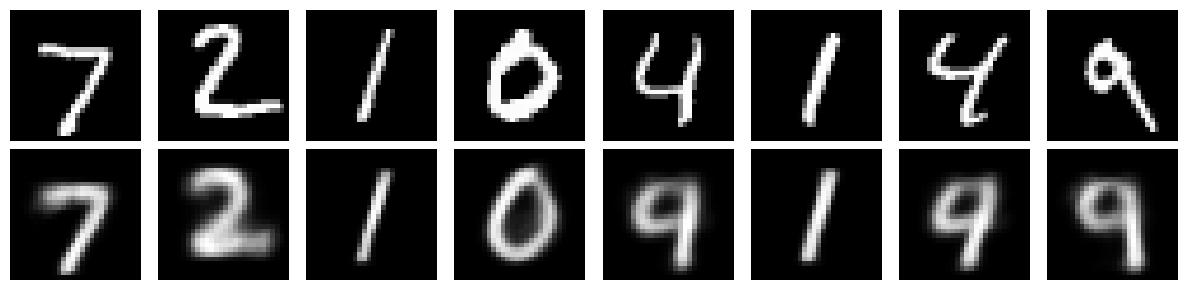

======> Test set loss: 146.1154


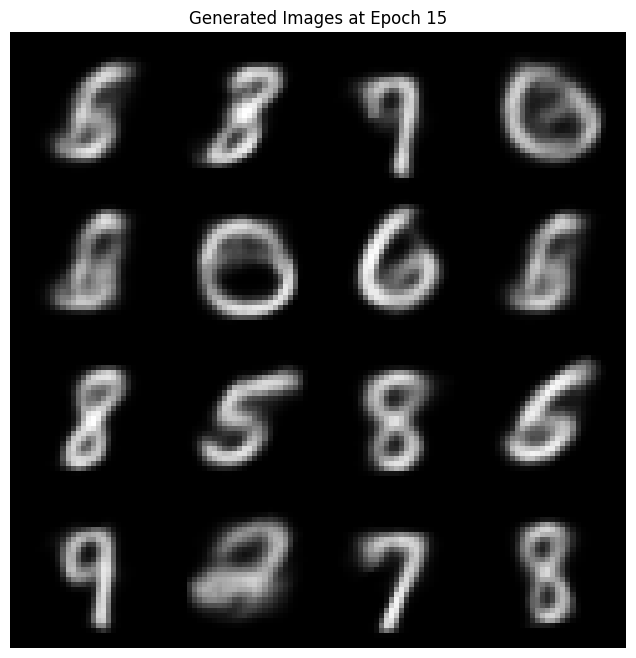

Train Epoch: 16 [0/60000 (0%)]	Loss: 147.937627
Train Epoch: 16 [10000/60000 (17%)]	Loss: 146.949746
Train Epoch: 16 [20000/60000 (33%)]	Loss: 146.954912
Train Epoch: 16 [30000/60000 (50%)]	Loss: 152.125762
Train Epoch: 16 [40000/60000 (67%)]	Loss: 143.184238
Train Epoch: 16 [50000/60000 (83%)]	Loss: 147.876611
======> Epoch: 16 Average loss: 145.6159


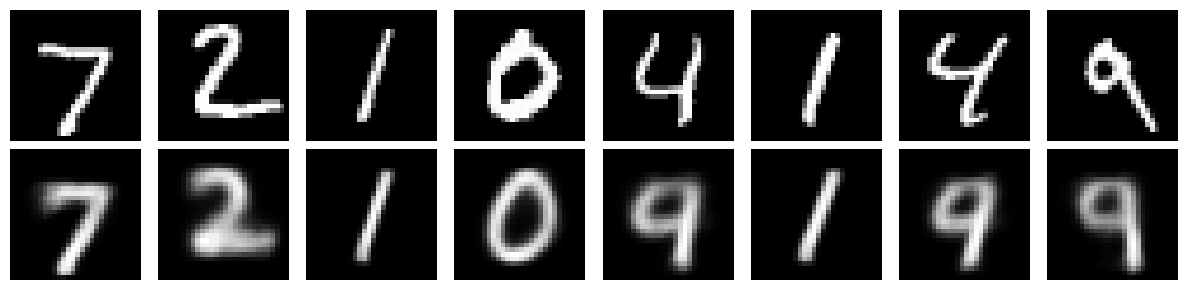

======> Test set loss: 146.6713


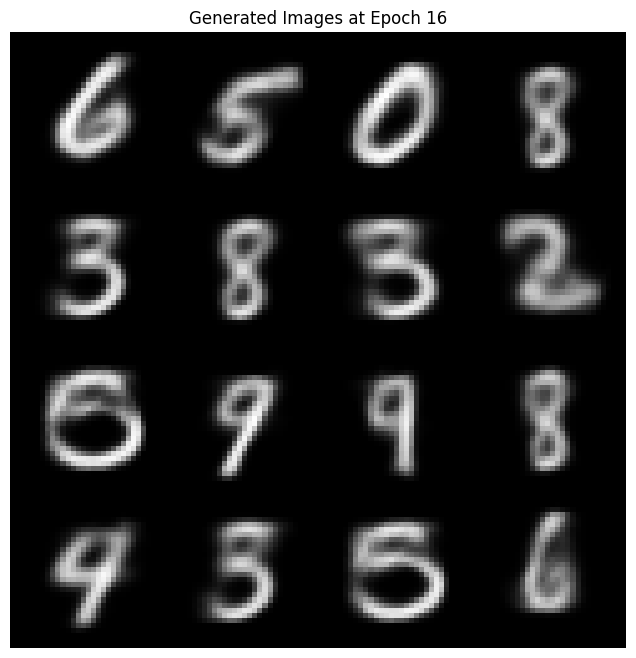

Train Epoch: 17 [0/60000 (0%)]	Loss: 146.359951
Train Epoch: 17 [10000/60000 (17%)]	Loss: 144.488662
Train Epoch: 17 [20000/60000 (33%)]	Loss: 137.312500
Train Epoch: 17 [30000/60000 (50%)]	Loss: 133.853838
Train Epoch: 17 [40000/60000 (67%)]	Loss: 141.739541
Train Epoch: 17 [50000/60000 (83%)]	Loss: 146.075029
======> Epoch: 17 Average loss: 145.1911


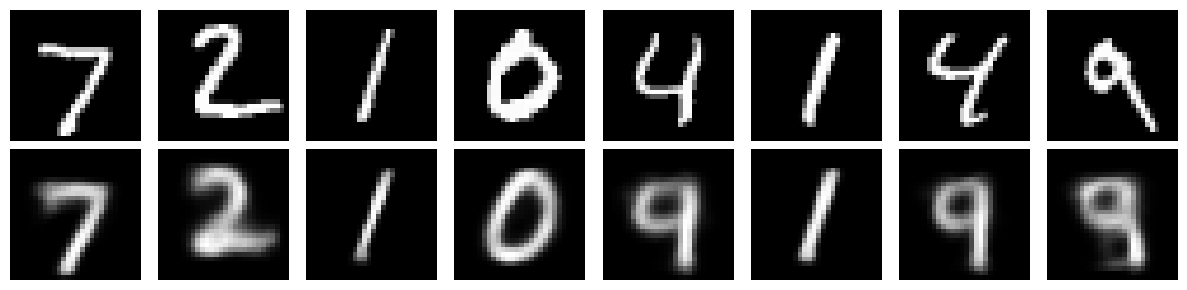

======> Test set loss: 145.7320


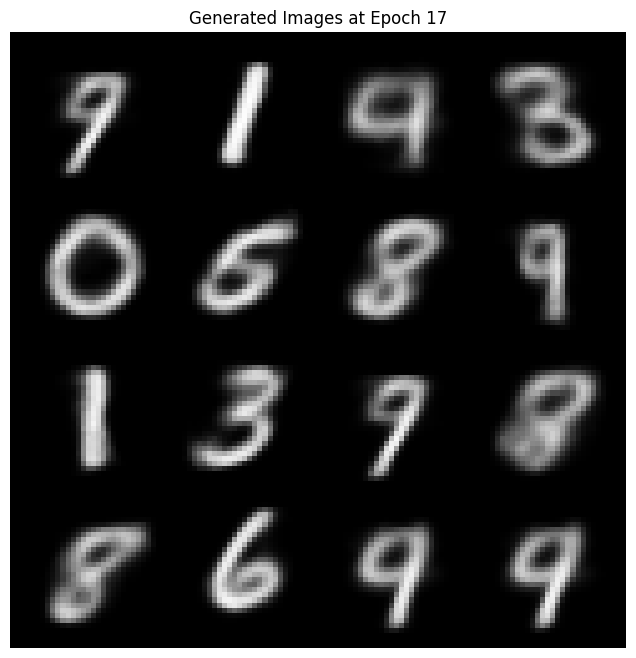

Train Epoch: 18 [0/60000 (0%)]	Loss: 151.906572
Train Epoch: 18 [10000/60000 (17%)]	Loss: 143.534033
Train Epoch: 18 [20000/60000 (33%)]	Loss: 141.335283
Train Epoch: 18 [30000/60000 (50%)]	Loss: 147.189170
Train Epoch: 18 [40000/60000 (67%)]	Loss: 147.775742
Train Epoch: 18 [50000/60000 (83%)]	Loss: 150.064980
======> Epoch: 18 Average loss: 145.2206


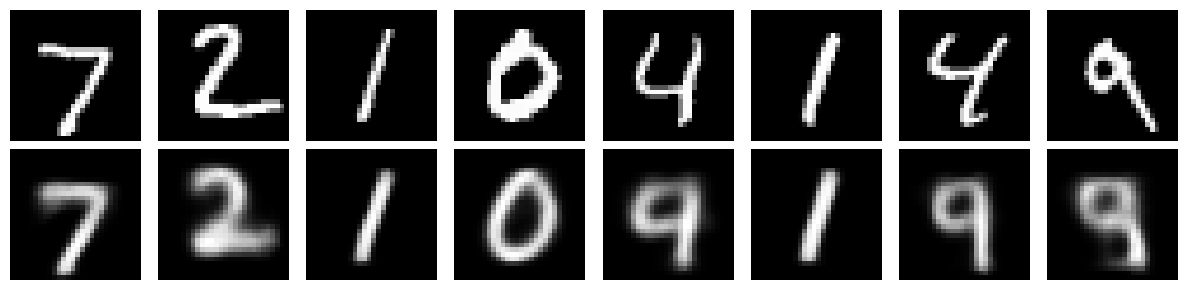

======> Test set loss: 145.5069


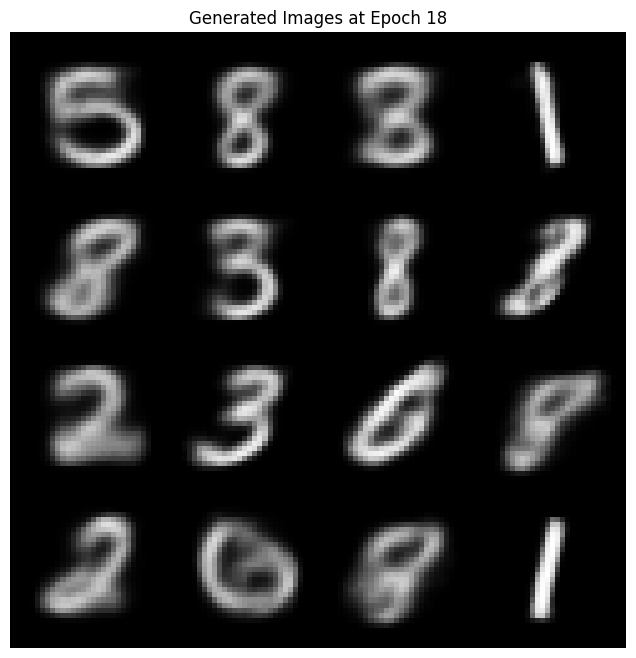

Train Epoch: 19 [0/60000 (0%)]	Loss: 147.369131
Train Epoch: 19 [10000/60000 (17%)]	Loss: 142.170645
Train Epoch: 19 [20000/60000 (33%)]	Loss: 144.114414
Train Epoch: 19 [30000/60000 (50%)]	Loss: 141.133115
Train Epoch: 19 [40000/60000 (67%)]	Loss: 143.356689
Train Epoch: 19 [50000/60000 (83%)]	Loss: 140.756299
======> Epoch: 19 Average loss: 144.7435


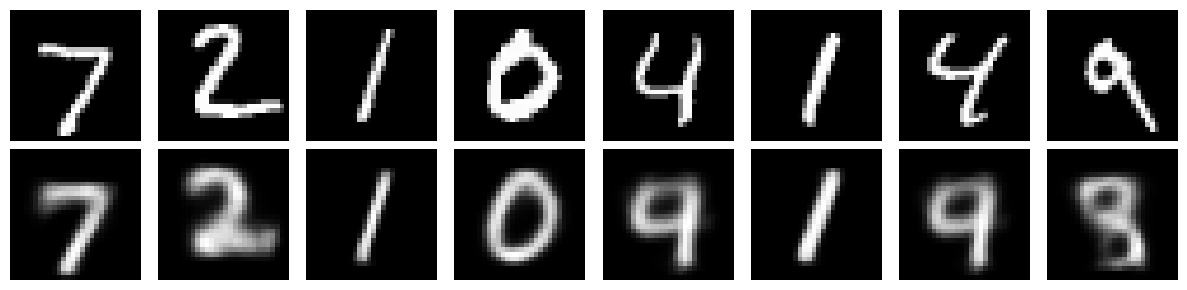

======> Test set loss: 145.7206


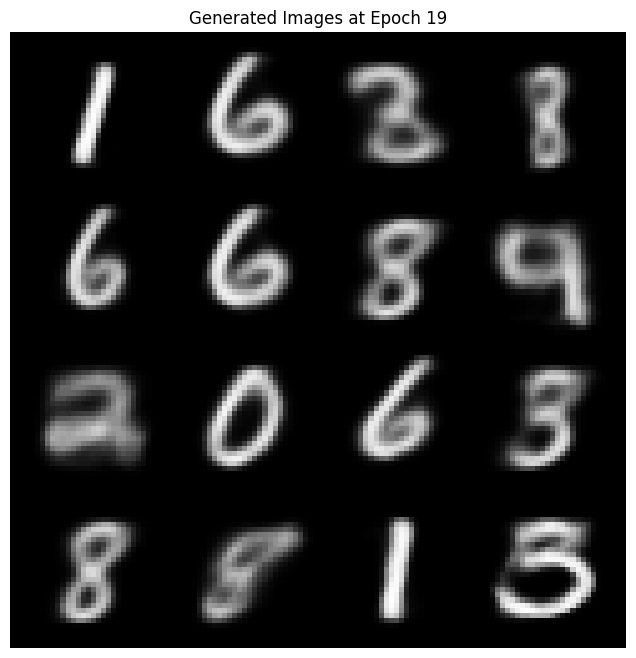

Train Epoch: 20 [0/60000 (0%)]	Loss: 142.116758
Train Epoch: 20 [10000/60000 (17%)]	Loss: 149.477432
Train Epoch: 20 [20000/60000 (33%)]	Loss: 147.869873
Train Epoch: 20 [30000/60000 (50%)]	Loss: 146.494463
Train Epoch: 20 [40000/60000 (67%)]	Loss: 146.281514
Train Epoch: 20 [50000/60000 (83%)]	Loss: 136.536523
======> Epoch: 20 Average loss: 144.5490


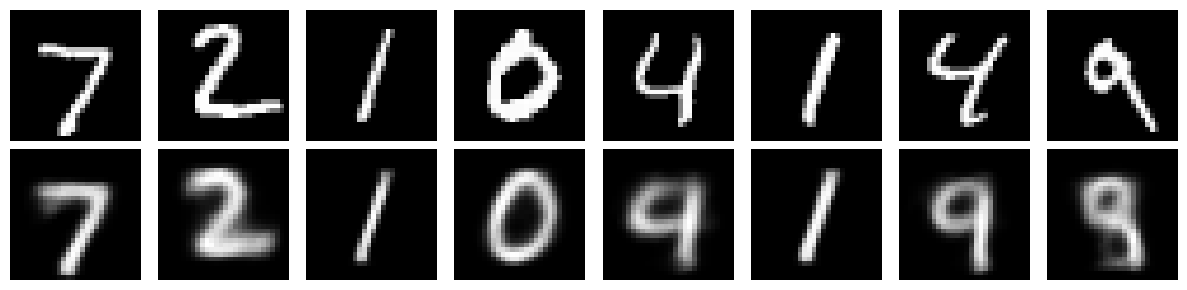

======> Test set loss: 144.8605


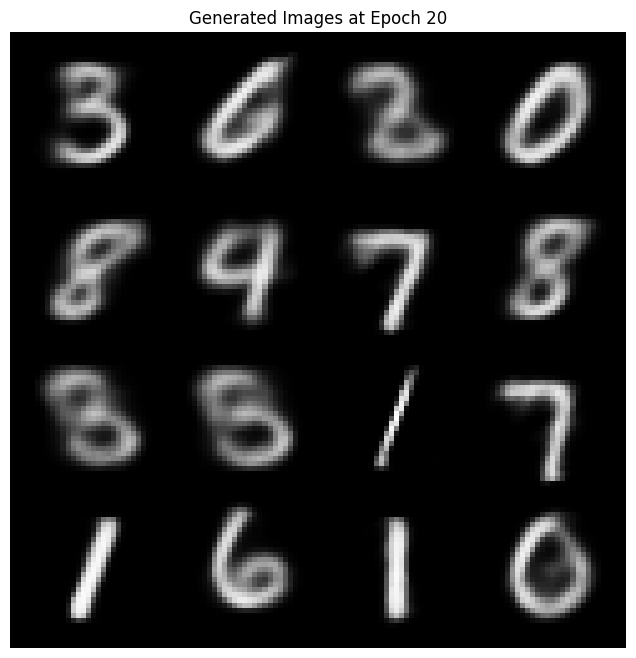

Train Epoch: 21 [0/60000 (0%)]	Loss: 136.956572
Train Epoch: 21 [10000/60000 (17%)]	Loss: 144.840068
Train Epoch: 21 [20000/60000 (33%)]	Loss: 147.612051
Train Epoch: 21 [30000/60000 (50%)]	Loss: 147.466895
Train Epoch: 21 [40000/60000 (67%)]	Loss: 141.159004
Train Epoch: 21 [50000/60000 (83%)]	Loss: 144.336855
======> Epoch: 21 Average loss: 144.4566


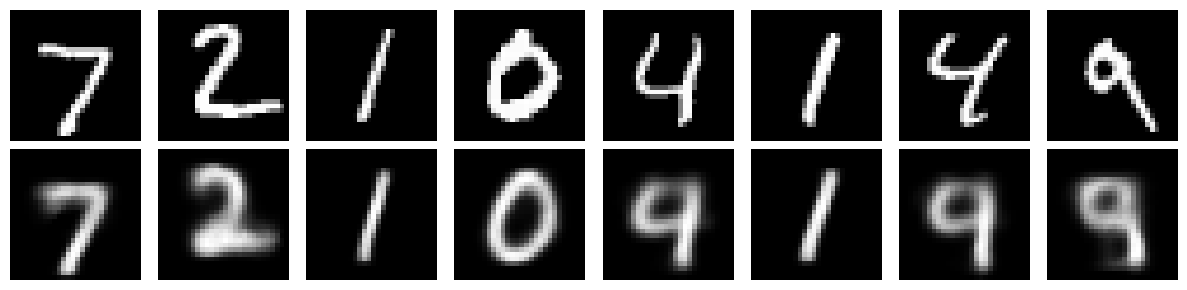

======> Test set loss: 144.8626


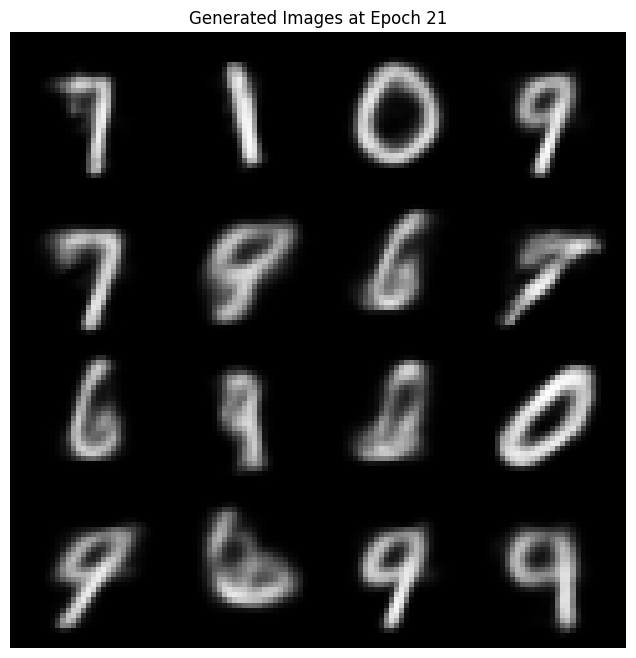

Train Epoch: 22 [0/60000 (0%)]	Loss: 137.152764
Train Epoch: 22 [10000/60000 (17%)]	Loss: 149.273281
Train Epoch: 22 [20000/60000 (33%)]	Loss: 144.923076
Train Epoch: 22 [30000/60000 (50%)]	Loss: 152.368311
Train Epoch: 22 [40000/60000 (67%)]	Loss: 141.695371
Train Epoch: 22 [50000/60000 (83%)]	Loss: 147.423623
======> Epoch: 22 Average loss: 144.2540


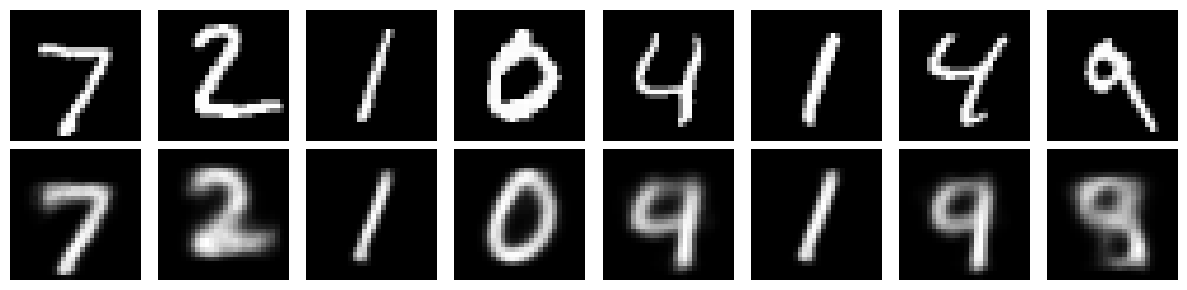

======> Test set loss: 145.3490


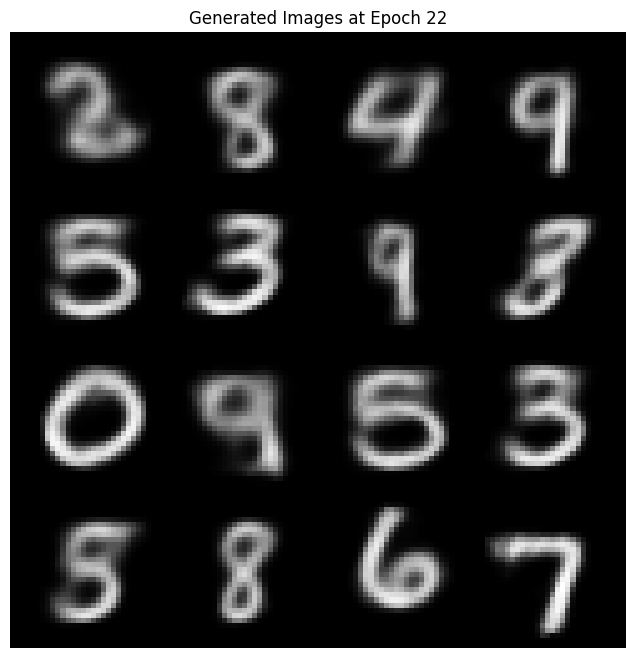

Train Epoch: 23 [0/60000 (0%)]	Loss: 143.137285
Train Epoch: 23 [10000/60000 (17%)]	Loss: 142.912207
Train Epoch: 23 [20000/60000 (33%)]	Loss: 140.941182
Train Epoch: 23 [30000/60000 (50%)]	Loss: 156.596807
Train Epoch: 23 [40000/60000 (67%)]	Loss: 139.754717
Train Epoch: 23 [50000/60000 (83%)]	Loss: 147.627813
======> Epoch: 23 Average loss: 143.9423


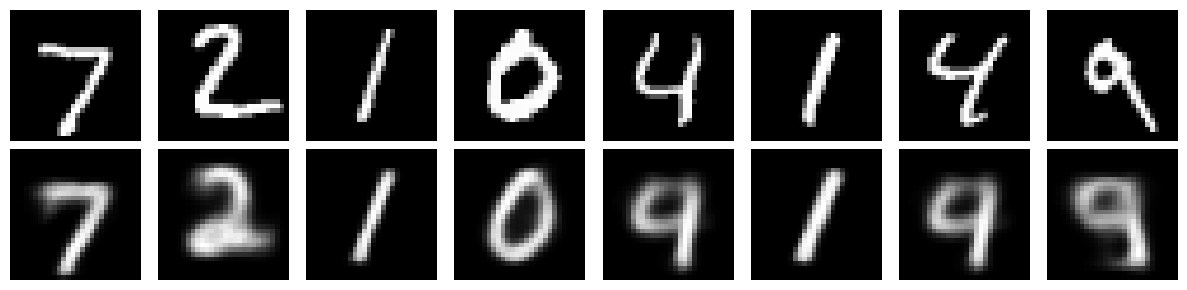

======> Test set loss: 146.4350


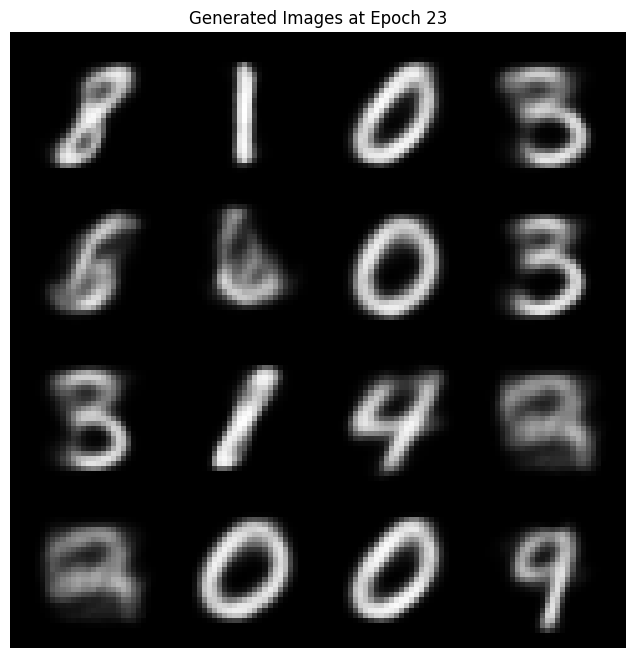

Train Epoch: 24 [0/60000 (0%)]	Loss: 140.367266
Train Epoch: 24 [10000/60000 (17%)]	Loss: 142.677637
Train Epoch: 24 [20000/60000 (33%)]	Loss: 145.073613
Train Epoch: 24 [30000/60000 (50%)]	Loss: 148.398652
Train Epoch: 24 [40000/60000 (67%)]	Loss: 140.348301
Train Epoch: 24 [50000/60000 (83%)]	Loss: 151.230811
======> Epoch: 24 Average loss: 143.6861


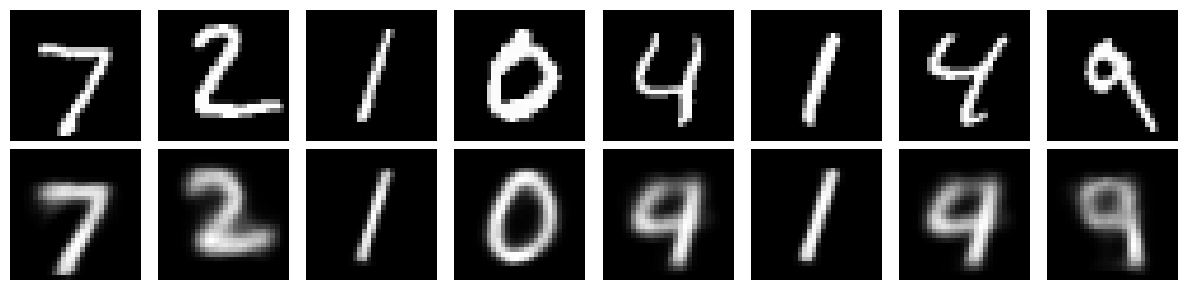

======> Test set loss: 145.4165


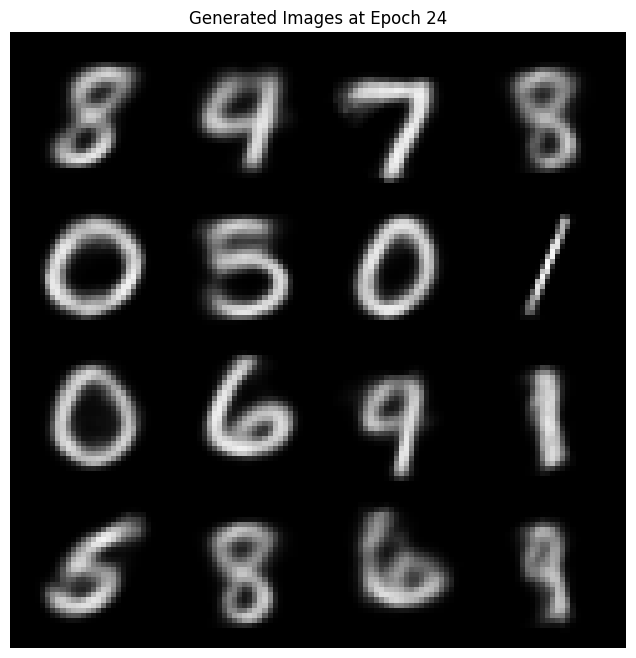

Train Epoch: 25 [0/60000 (0%)]	Loss: 140.059893
Train Epoch: 25 [10000/60000 (17%)]	Loss: 150.827520
Train Epoch: 25 [20000/60000 (33%)]	Loss: 142.615801
Train Epoch: 25 [30000/60000 (50%)]	Loss: 136.010605
Train Epoch: 25 [40000/60000 (67%)]	Loss: 135.226689
Train Epoch: 25 [50000/60000 (83%)]	Loss: 139.403721
======> Epoch: 25 Average loss: 143.5081


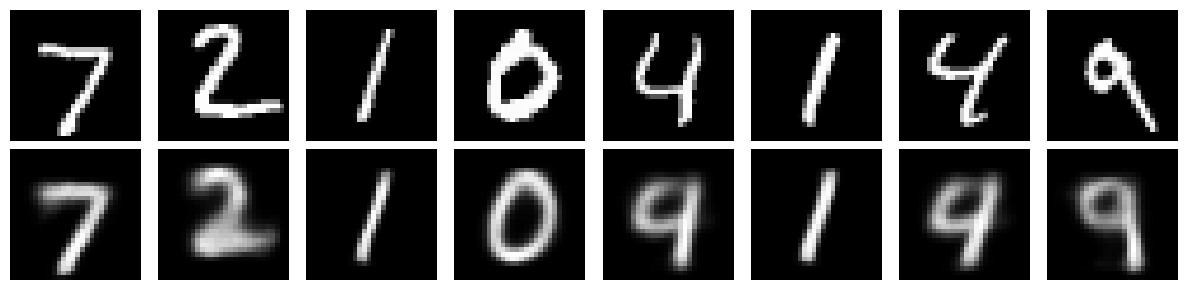

======> Test set loss: 144.6763


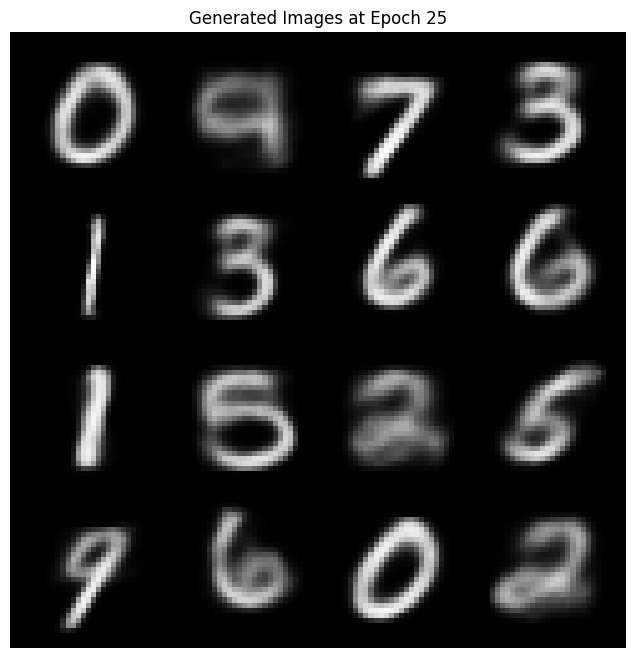

Train Epoch: 26 [0/60000 (0%)]	Loss: 144.788965
Train Epoch: 26 [10000/60000 (17%)]	Loss: 141.396963
Train Epoch: 26 [20000/60000 (33%)]	Loss: 144.419834
Train Epoch: 26 [30000/60000 (50%)]	Loss: 135.711533
Train Epoch: 26 [40000/60000 (67%)]	Loss: 146.781631
Train Epoch: 26 [50000/60000 (83%)]	Loss: 136.743086
======> Epoch: 26 Average loss: 143.3195


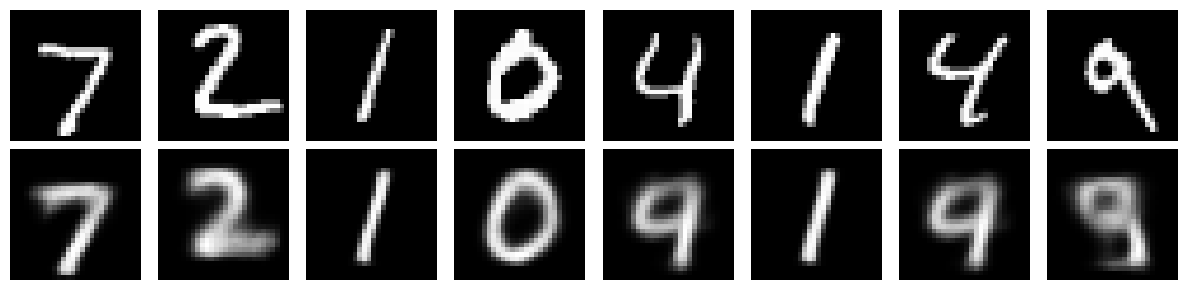

======> Test set loss: 145.5382


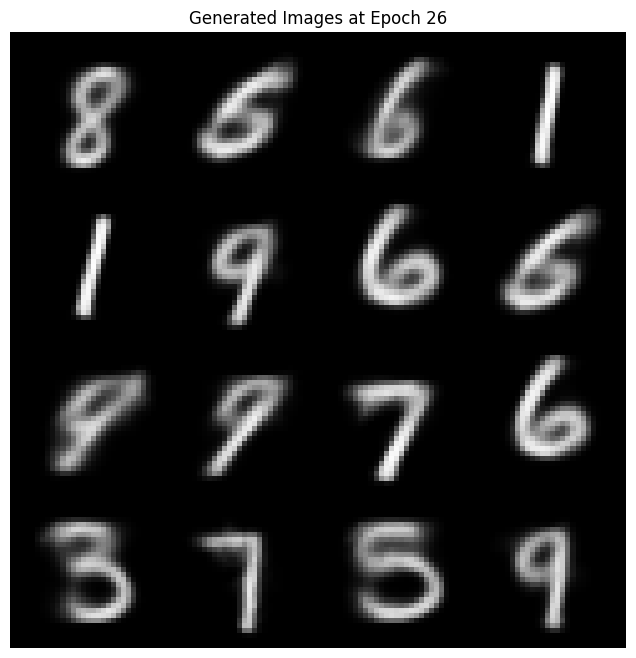

Train Epoch: 27 [0/60000 (0%)]	Loss: 138.778320
Train Epoch: 27 [10000/60000 (17%)]	Loss: 139.946934
Train Epoch: 27 [20000/60000 (33%)]	Loss: 142.621758
Train Epoch: 27 [30000/60000 (50%)]	Loss: 144.297744
Train Epoch: 27 [40000/60000 (67%)]	Loss: 146.497588
Train Epoch: 27 [50000/60000 (83%)]	Loss: 143.061221
======> Epoch: 27 Average loss: 143.1615


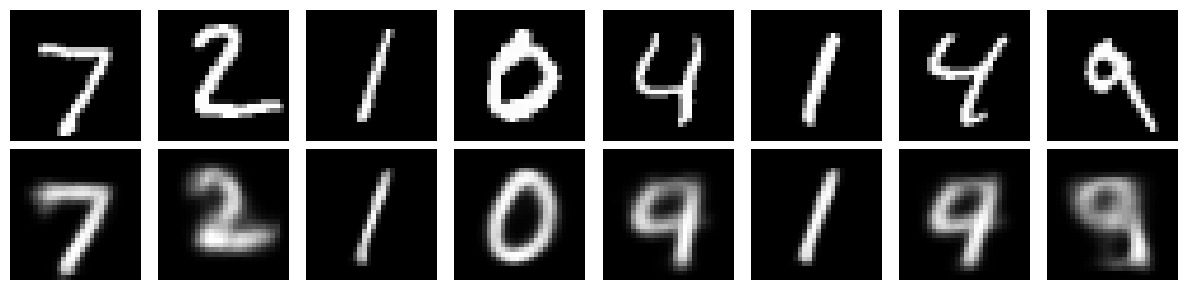

======> Test set loss: 145.3669


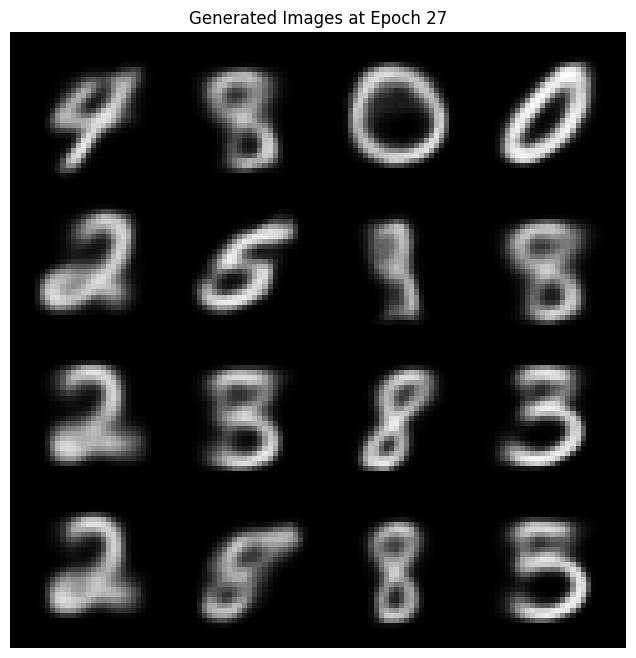

Train Epoch: 28 [0/60000 (0%)]	Loss: 142.979814
Train Epoch: 28 [10000/60000 (17%)]	Loss: 145.177168
Train Epoch: 28 [20000/60000 (33%)]	Loss: 143.353516
Train Epoch: 28 [30000/60000 (50%)]	Loss: 136.587861
Train Epoch: 28 [40000/60000 (67%)]	Loss: 140.209893
Train Epoch: 28 [50000/60000 (83%)]	Loss: 137.091592
======> Epoch: 28 Average loss: 143.0500


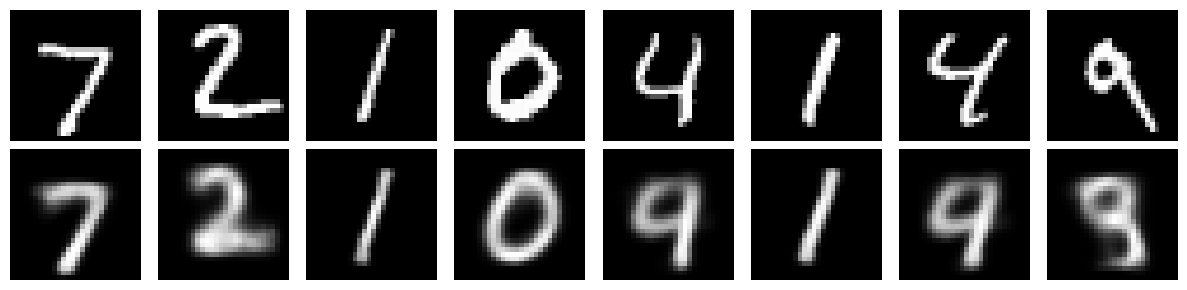

======> Test set loss: 144.2492


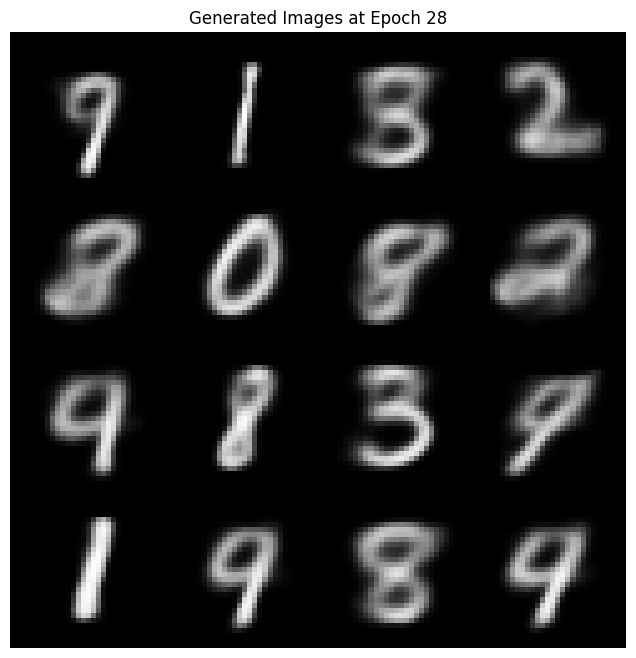

Train Epoch: 29 [0/60000 (0%)]	Loss: 145.930391
Train Epoch: 29 [10000/60000 (17%)]	Loss: 138.691455
Train Epoch: 29 [20000/60000 (33%)]	Loss: 149.775420
Train Epoch: 29 [30000/60000 (50%)]	Loss: 142.361094
Train Epoch: 29 [40000/60000 (67%)]	Loss: 145.331045
Train Epoch: 29 [50000/60000 (83%)]	Loss: 143.263828
======> Epoch: 29 Average loss: 142.6904


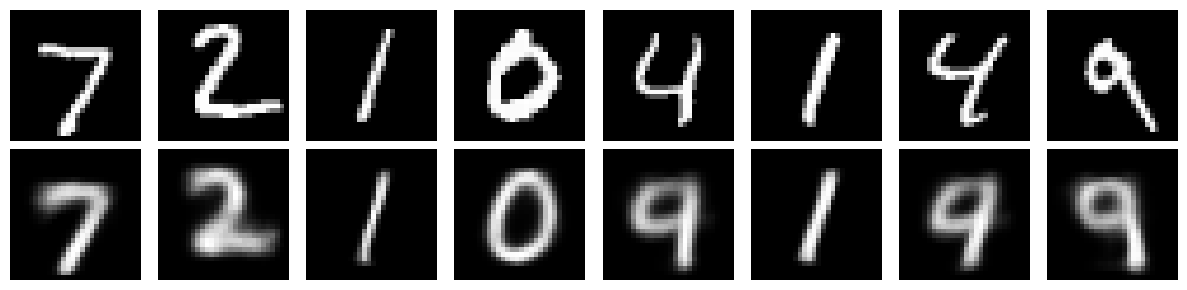

======> Test set loss: 144.5009


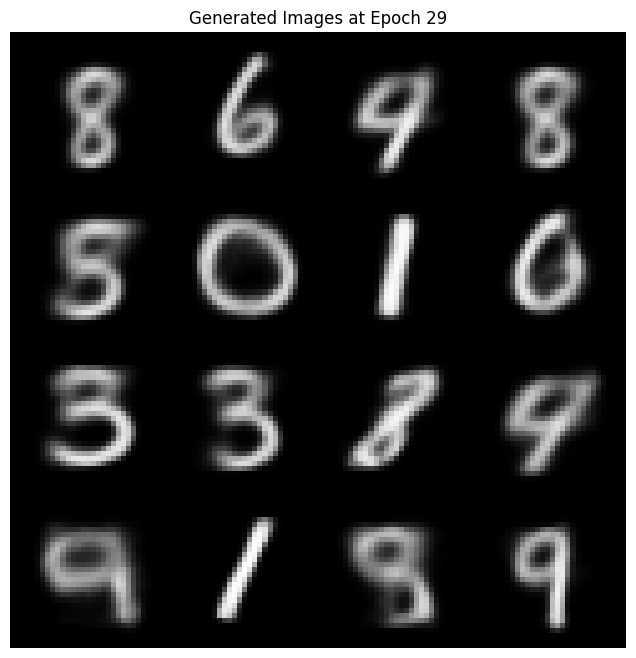

Train Epoch: 30 [0/60000 (0%)]	Loss: 136.852188
Train Epoch: 30 [10000/60000 (17%)]	Loss: 137.176113
Train Epoch: 30 [20000/60000 (33%)]	Loss: 136.852695
Train Epoch: 30 [30000/60000 (50%)]	Loss: 138.024512
Train Epoch: 30 [40000/60000 (67%)]	Loss: 141.353330
Train Epoch: 30 [50000/60000 (83%)]	Loss: 144.861846
======> Epoch: 30 Average loss: 142.5363


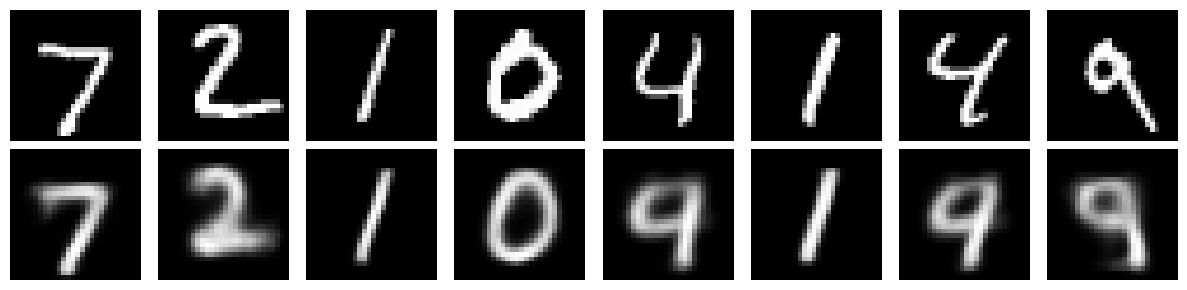

======> Test set loss: 144.6335


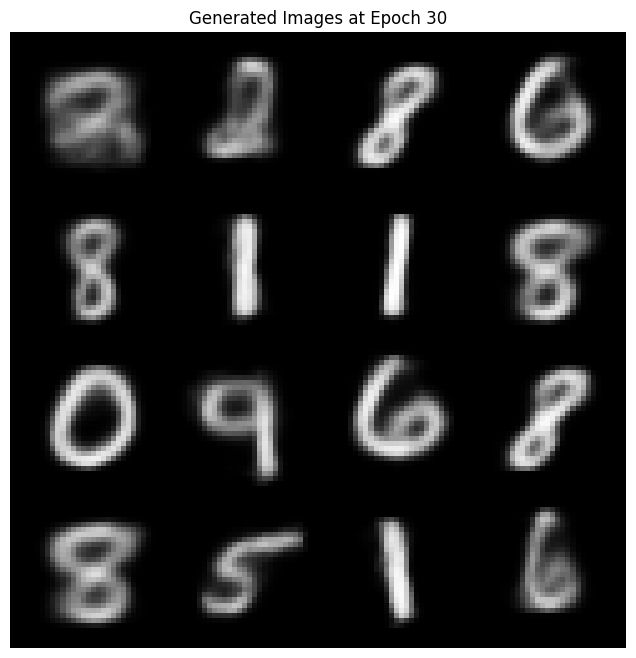

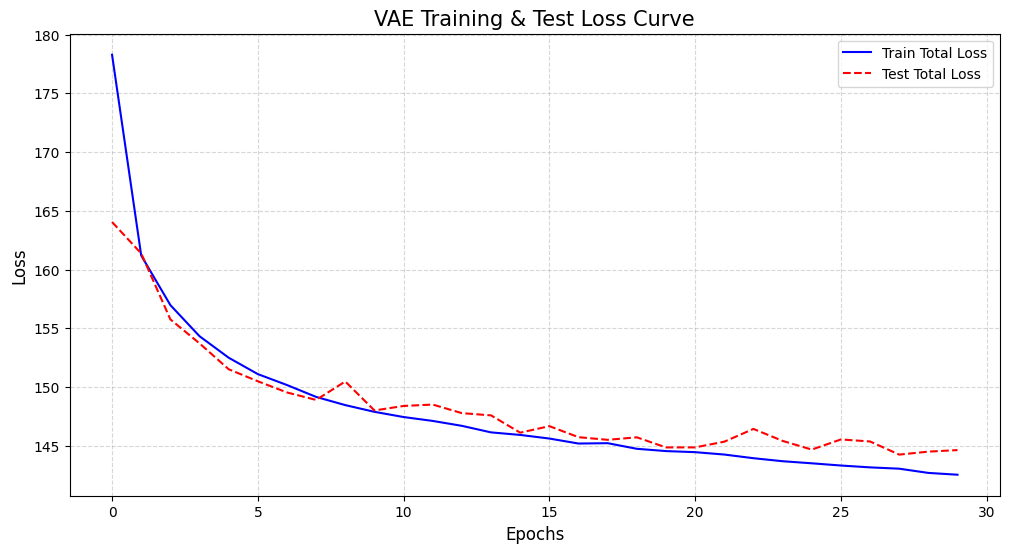

In [13]:
#13) 전체 학습 및 평가 실행

# 훈련 과정을 시각적으로 확인하기 위한 진행 바(Progress Bar) 라이브러리
from tqdm.auto import tqdm

# 학습 결과를 저장할 딕셔너리 (나중에 손실 곡선을 그릴 때 사용)
history = {'train_loss': [], 'test_loss': []}


# 설정한 에폭(epochs)만큼 반복 학습 및 평가 진행
for epoch in tqdm(range(1, epochs + 1)): 
    # 1. 한 에폭 동안 학습 수행 (가중치 업데이트)
    train_avg_loss = train(epoch, model, train_loader, optimizer)
    history['train_loss'].append(train_avg_loss)
    
    # 2. 한 에폭 종료 후 평가 수행 (복원 성능 확인)
    test_avg_loss = test(epoch, model, test_loader)
    history['test_loss'].append(test_avg_loss)
    
    # 3. 모델의 생성 능력 확인 (잠재 공간에서 무작위 샘플링)
    # 매 에폭마다 모델이 얼마나 '그럴듯한' 숫자를 만들어내는지 관찰할 수 있습니다.
    generate_images(epoch, model, n=16)
    
    
# 4. 모든 학습이 끝난 후 손실 곡선 출력
plot_loss_curve(history)


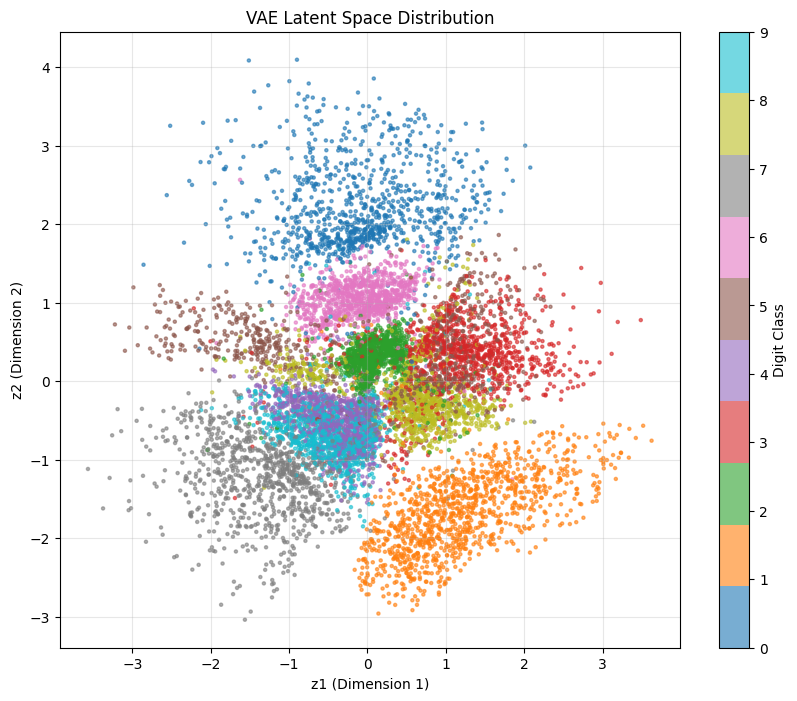

In [14]:
def plot_latent_space(model, test_loader, device):
    model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(-1, 784).to(device)
            # 인코더를 통해 잠재 공간의 평균(μ) 벡터 추출
            mu, _ = model.Encoder(x)
            latents.append(mu.cpu())
            labels.append(y)
            
    # 리스트를 하나의 넘파이 배열로 통합
    latents = torch.cat(latents, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    
    plt.figure(figsize=(10, 8))
    # latent_dim이 2일 때를 가정하여 첫 두 차원 시각화
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=5)
    plt.colorbar(scatter, label='Digit Class')
    plt.title('VAE Latent Space Distribution')
    plt.xlabel('z1 (Dimension 1)')
    plt.ylabel('z2 (Dimension 2)')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_latent_space(model, test_loader, device)

In [15]:
########### latent_dim = 2 # 잠재 공간 차원  ############

def plot_latent_manifold(model, n=20, range_limit=2):
    """
    z1, z2 평면의 격자를 따라 이미지를 생성하여 시각화
    """
    model.eval()
    # -range_limit부터 range_limit까지 n단계로 나누어 좌표 생성 (표준정규분포 범위 고려)
    grid_x = np.linspace(-range_limit, range_limit, n)
    grid_y = np.linspace(-range_limit, range_limit, n)
    
    # 전체 그리드 이미지 담을 캔버스 생성
    canvas = np.empty((28 * n, 28 * n))
    
    with torch.no_grad():
        for i, yi in enumerate(grid_x):
            for j, xi in enumerate(grid_y):
                # 격자 좌표로부터 잠재 벡터 z 생성
                z = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
                # 디코더를 통해 이미지 복원
                x_hat = model.Decoder(z).cpu().view(28, 28).numpy()
                # 캔버스의 해당 위치에 삽입
                canvas[(n - i - 1) * 28:(n - i) * 28, j * 28:(j * 1 + 1) * 28] = x_hat

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap='gray')
    plt.title('Learned Latent Manifold (z1 vs z2)')
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.axis('off')
    plt.show()

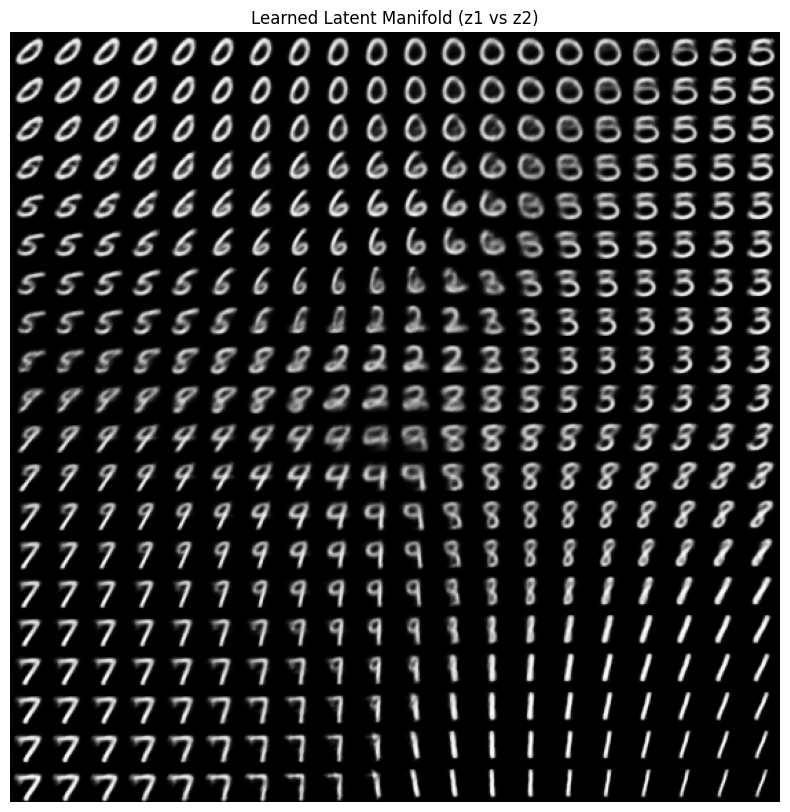

In [16]:
plot_latent_manifold(model, n=20, range_limit=2)